# Sales Forecasting — Baseline+
**Goal:** Predict daily `Revenue` and `COGS` for 2023-01-01 → 2024-07-01 using historical data (2012–2022).

**Strategy (improved baseline):**
1. Build a recency-weighted seasonal profile by **(month, day)**.
2. Estimate YoY growth and calibrate damping on a validation tail (2021–2022).
3. Add weekday + promotion/holiday/Tet residual adjustments.
4. Backtest quickly, then export submission.

## 1 — Imports & Config

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path('.')
TRAIN_FILE = DATA_DIR / 'analytical' / 'sales.csv'
TEST_FILE = DATA_DIR / 'analytical' / 'sample_submission.csv'
PROMO_FILE = DATA_DIR / 'master' / 'promotions.csv'

OUT_DIR = Path('../data_cleaned/forecast')
OUT_FILE = OUT_DIR / 'baseline_plus_submission.csv'
OUT_FILE_CANONICAL = OUT_DIR / 'submission.csv'

## 2 — Load & Inspect Data

In [34]:
train = pd.read_csv(TRAIN_FILE, parse_dates=['Date']).sort_values('Date').reset_index(drop=True)
test  = pd.read_csv(TEST_FILE,  parse_dates=['Date']).sort_values('Date').reset_index(drop=True)

if PROMO_FILE.exists():
    promo = pd.read_csv(PROMO_FILE, parse_dates=['start_date', 'end_date'])
else:
    promo = pd.DataFrame(columns=['start_date', 'end_date', 'discount_value'])

if 'discount_value' not in promo.columns:
    promo['discount_value'] = 0.0
promo['discount_value'] = promo['discount_value'].fillna(0.0).astype(float)

print('Train shape:', train.shape)
print('Train date range:', train['Date'].min().date(), '→', train['Date'].max().date())
print()
print('Test shape:', test.shape)
print('Test date range:', test['Date'].min().date(), '→', test['Date'].max().date())
print('Promo rows:', len(promo))
print()
train.tail()

Train shape: (3833, 3)
Train date range: 2012-07-04 → 2022-12-31

Test shape: (548, 3)
Test date range: 2023-01-01 → 2024-07-01
Promo rows: 50



,Date,Revenue,COGS
3828,2022-12-27,2100553.66,2184872.24
3829,2022-12-28,3448729.20,3513621.00
3830,2022-12-29,3083944.33,3170787.10
3831,2022-12-30,2884668.76,3022292.15
3832,2022-12-31,2383037.48,2279288.13


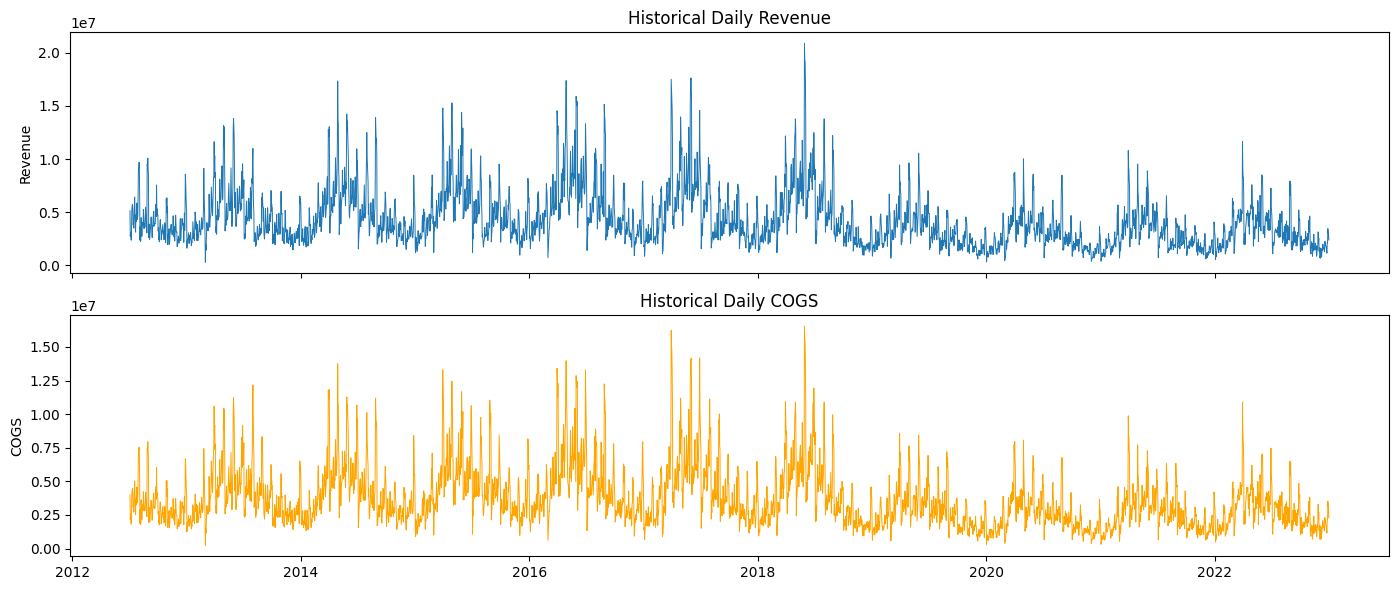

In [35]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(train['Date'], train['Revenue'], lw=0.7)
axes[0].set_title('Historical Daily Revenue'); axes[0].set_ylabel('Revenue')
axes[1].plot(train['Date'], train['COGS'], lw=0.7, color='orange')
axes[1].set_title('Historical Daily COGS'); axes[1].set_ylabel('COGS')
plt.tight_layout()
plt.show()

## 3 — Feature Engineering

In [36]:
for df in (train, test):
    df['year']    = df['Date'].dt.year
    df['month']   = df['Date'].dt.month
    df['day']     = df['Date'].dt.day
    df['weekday'] = df['Date'].dt.weekday

# Annual totals for trend estimation
annual = train.groupby('year')[['Revenue', 'COGS']].sum()

# Annual means to normalize within year
annual_means = (
    train.groupby('year')[['Revenue', 'COGS']]
    .mean()
    .rename(columns={'Revenue': 'annual_rev_mean', 'COGS': 'annual_cogs_mean'})
)
train = train.merge(annual_means, left_on='year', right_index=True, how='left')

print('Annual totals:')
print(annual)

Annual totals:
           Revenue          COGS
year                            
2012  7.414977e+08  5.874619e+08
2013  1.657169e+09  1.465980e+09
2014  1.871846e+09  1.574607e+09
2015  1.889934e+09  1.665442e+09
2016  2.104641e+09  1.780559e+09
2017  1.911164e+09  1.694386e+09
2018  1.850122e+09  1.542176e+09
2019  1.136801e+09  1.005203e+09
2020  1.054512e+09  8.860851e+08
2021  1.043040e+09  9.411301e+08
2022  1.169749e+09  1.020420e+09


In [37]:
# --- Raw YoY growth (geometric mean, 2013–2022) ---
full_years = annual.loc[2013:2022].copy()

yoy_rev  = full_years['Revenue'].pct_change().dropna()
yoy_cogs = full_years['COGS'].pct_change().dropna()

raw_growth_rev  = (1 + yoy_rev).prod() ** (1 / len(yoy_rev))
raw_growth_cogs = (1 + yoy_cogs).prod() ** (1 / len(yoy_cogs))

print(f'Raw geometric YoY Revenue growth : {raw_growth_rev:.4f}  ({(raw_growth_rev-1)*100:.2f}%/yr)')
print(f'Raw geometric YoY COGS    growth : {raw_growth_cogs:.4f}  ({(raw_growth_cogs-1)*100:.2f}%/yr)')

Raw geometric YoY Revenue growth : 0.9620  (-3.80%/yr)
Raw geometric YoY COGS    growth : 0.9605  (-3.95%/yr)


## 4 — Build Recency-Weighted Seasonal + Weekday Profiles

Use normalized values and higher weight for recent years to reduce old-pattern bias.

In [38]:
train['year_weight'] = (train['year'] - train['year'].min() + 1).astype(float)

train['rev_norm'] = train['Revenue'] / train['annual_rev_mean'].replace(0, np.nan)
train['cogs_norm'] = train['COGS'] / train['annual_cogs_mean'].replace(0, np.nan)
train['rev_norm'] = train['rev_norm'].replace([np.inf, -np.inf], np.nan).fillna(1.0)
train['cogs_norm'] = train['cogs_norm'].replace([np.inf, -np.inf], np.nan).fillna(1.0)

def wavg(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    if np.sum(weights) <= 0:
        return float(np.mean(values))
    return float(np.average(values, weights=weights))

seasonal = (
    train.groupby(['month', 'day'])
    .apply(lambda g: pd.Series({
        'rev_norm': wavg(g['rev_norm'], g['year_weight']),
        'cogs_norm': wavg(g['cogs_norm'], g['year_weight']),
    }))
    .reset_index()
)

train_season = train.merge(seasonal, on=['month', 'day'], how='left', suffixes=('', '_season'))
train_season['rev_resid'] = train_season['Revenue'] / (train_season['annual_rev_mean'] * train_season['rev_norm_season']).replace(0, np.nan)
train_season['cogs_resid'] = train_season['COGS'] / (train_season['annual_cogs_mean'] * train_season['cogs_norm_season']).replace(0, np.nan)

weekday_profile = (
    train_season.groupby('weekday')[['rev_resid', 'cogs_resid']]
    .median()
    .rename(columns={'rev_resid': 'rev_wday_factor', 'cogs_resid': 'cogs_wday_factor'})
    .reset_index()
)
weekday_profile['rev_wday_factor'] = weekday_profile['rev_wday_factor'].fillna(1.0).clip(0.85, 1.15)
weekday_profile['cogs_wday_factor'] = weekday_profile['cogs_wday_factor'].fillna(1.0).clip(0.85, 1.15)

print('Seasonal profile rows:', len(seasonal))
print('Weekday profile rows:', len(weekday_profile))
display(seasonal.head(10))
display(weekday_profile)

Seasonal profile rows: 366
Weekday profile rows: 7


,month,day,rev_norm,cogs_norm
0,1,1,0.801819,0.892686
1,1,2,0.400083,0.413737
2,1,3,0.292226,0.273023
3,1,4,0.346435,0.317989
4,1,5,0.383339,0.352024
5,1,6,0.396382,0.367514
6,1,7,0.404590,0.380558
7,1,8,0.457094,0.426858
8,1,9,0.478655,0.454329
9,1,10,0.517271,0.480715


,weekday,rev_wday_factor,cogs_wday_factor
0,0,1.031772,1.026682
1,1,1.040853,1.036052
2,2,1.062912,1.059007
3,3,1.037391,1.037858
4,4,0.918557,0.921414
5,5,0.914254,0.909829
6,6,0.954258,0.957094


## 5 — Predict Test Period (Calibrated Baseline+)

Calibrate growth damping on 2021–2022, then apply weekday and event adjustments.

In [39]:
base_year = 2022 if 2022 in annual.index else int(annual.index.max())
base_rev = annual.loc[base_year, 'Revenue'] / 365.0
base_cogs = annual.loc[base_year, 'COGS'] / 365.0

seasonal_model = seasonal.rename(columns={'rev_norm': 'rev_norm_season', 'cogs_norm': 'cogs_norm_season'})

cal = train.merge(seasonal_model, on=['month', 'day'], how='left').merge(weekday_profile, on='weekday', how='left')
cal['rev_norm'] = cal['rev_norm_season'].fillna(1.0)
cal['cogs_norm'] = cal['cogs_norm_season'].fillna(1.0)
cal['rev_wday_factor'] = cal['rev_wday_factor'].fillna(1.0)
cal['cogs_wday_factor'] = cal['cogs_wday_factor'].fillna(1.0)

cal['years_ahead'] = cal['year'] - base_year
val_mask = cal['year'].isin([2021, 2022])
cal_val = cal.loc[val_mask].copy()

def mape(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    eps = 1e-9
    return float(np.mean(np.abs(actual - pred) / (np.abs(actual) + eps)))

candidate_lam = np.linspace(0.0, 1.0, 11)
best_lam_rev, best_lam_cogs = 1.0, 1.0
best_mape_rev, best_mape_cogs = np.inf, np.inf

for lam in candidate_lam:
    g_rev = 1.0 + lam * (raw_growth_rev - 1.0)
    rev_pred = base_rev * (g_rev ** cal_val['years_ahead']) * cal_val['rev_norm'] * cal_val['rev_wday_factor']
    rev_score = mape(cal_val['Revenue'], rev_pred)
    if rev_score < best_mape_rev:
        best_mape_rev = rev_score
        best_lam_rev = float(lam)

for lam in candidate_lam:
    g_cogs = 1.0 + lam * (raw_growth_cogs - 1.0)
    cogs_pred = base_cogs * (g_cogs ** cal_val['years_ahead']) * cal_val['cogs_norm'] * cal_val['cogs_wday_factor']
    cogs_score = mape(cal_val['COGS'], cogs_pred)
    if cogs_score < best_mape_cogs:
        best_mape_cogs = cogs_score
        best_lam_cogs = float(lam)

growth_rev = 1.0 + best_lam_rev * (raw_growth_rev - 1.0)
growth_cogs = 1.0 + best_lam_cogs * (raw_growth_cogs - 1.0)

# Build base predictions on train for residual event learning
cal['Revenue_pred_legacy'] = (base_rev * (raw_growth_rev ** cal['years_ahead']) * cal['rev_norm']).clip(lower=0)
cal['COGS_pred_legacy'] = (base_cogs * (raw_growth_cogs ** cal['years_ahead']) * cal['cogs_norm']).clip(lower=0)

cal_base_rev = (base_rev * (growth_rev ** cal['years_ahead']) * cal['rev_norm'] * cal['rev_wday_factor']).clip(lower=0)
cal_base_cogs = (base_cogs * (growth_cogs ** cal['years_ahead']) * cal['cogs_norm'] * cal['cogs_wday_factor']).clip(lower=0)

# Build test matrix
model_test = test.merge(seasonal_model, on=['month', 'day'], how='left').merge(weekday_profile, on='weekday', how='left')
model_test['rev_norm'] = model_test['rev_norm_season'].fillna(1.0)
model_test['cogs_norm'] = model_test['cogs_norm_season'].fillna(1.0)
model_test['rev_wday_factor'] = model_test['rev_wday_factor'].fillna(1.0)
model_test['cogs_wday_factor'] = model_test['cogs_wday_factor'].fillna(1.0)
model_test['years_ahead'] = model_test['year'] - base_year

def build_promo_daily(promo_df):
    if promo_df.empty:
        return pd.DataFrame(columns=['Date', 'promo_count', 'avg_discount'])

    chunks = []
    for _, r in promo_df.iterrows():
        start = r.get('start_date')
        end = r.get('end_date')
        if pd.isna(start) or pd.isna(end) or end < start:
            continue
        days = pd.date_range(start, end, freq='D')
        chunks.append(pd.DataFrame({
            'Date': days,
            'promo_count': 1.0,
            'discount_value': float(r.get('discount_value', 0.0) or 0.0),
        }))

    if not chunks:
        return pd.DataFrame(columns=['Date', 'promo_count', 'avg_discount'])

    return (
        pd.concat(chunks, ignore_index=True)
        .groupby('Date', as_index=False)
        .agg(promo_count=('promo_count', 'sum'), avg_discount=('discount_value', 'mean'))
    )

promo_daily = build_promo_daily(promo)

TET_DATE = {
    2013: pd.Timestamp('2013-02-10'),
    2014: pd.Timestamp('2014-01-31'),
    2015: pd.Timestamp('2015-02-19'),
    2016: pd.Timestamp('2016-02-08'),
    2017: pd.Timestamp('2017-01-28'),
    2018: pd.Timestamp('2018-02-16'),
    2019: pd.Timestamp('2019-02-05'),
    2020: pd.Timestamp('2020-01-25'),
    2021: pd.Timestamp('2021-02-12'),
    2022: pd.Timestamp('2022-02-01'),
    2023: pd.Timestamp('2023-01-22'),
    2024: pd.Timestamp('2024-02-10'),
}
fixed_holidays = {(1, 1), (4, 30), (5, 1), (9, 2), (12, 24), (12, 25), (12, 31)}

def is_tet_period(ts, pre_days=10, post_days=7):
    tet = TET_DATE.get(ts.year)
    if tet is None:
        return False
    return (tet - pd.Timedelta(days=pre_days)) <= ts <= (tet + pd.Timedelta(days=post_days))

def add_event_features(df):
    out = df.merge(promo_daily, on='Date', how='left')
    out['promo_count'] = out['promo_count'].fillna(0.0)
    out['avg_discount'] = out['avg_discount'].fillna(0.0)
    out['is_holiday'] = out['Date'].apply(lambda x: (x.month, x.day) in fixed_holidays)
    out['is_tet'] = out['Date'].apply(is_tet_period)
    return out

cal = add_event_features(cal)
model_test = add_event_features(model_test)

cal['rev_ratio'] = cal['Revenue'] / cal_base_rev.replace(0, np.nan)
cal['cogs_ratio'] = cal['COGS'] / cal_base_cogs.replace(0, np.nan)

global_rev_med = cal['rev_ratio'].dropna().median()
global_cogs_med = cal['cogs_ratio'].dropna().median()
if not np.isfinite(global_rev_med) or global_rev_med <= 0:
    global_rev_med = 1.0
if not np.isfinite(global_cogs_med) or global_cogs_med <= 0:
    global_cogs_med = 1.0

def median_ratio(series, mask, global_med):
    vals = series.loc[mask].dropna()
    if len(vals) == 0:
        return 1.0
    return float(np.clip(vals.median() / global_med, 0.7, 1.5))

promo_rev_mult = median_ratio(cal['rev_ratio'], cal['promo_count'] > 0, global_rev_med)
promo_cogs_mult = median_ratio(cal['cogs_ratio'], cal['promo_count'] > 0, global_cogs_med)
holiday_rev_mult = median_ratio(cal['rev_ratio'], cal['is_holiday'], global_rev_med)
holiday_cogs_mult = median_ratio(cal['cogs_ratio'], cal['is_holiday'], global_cogs_med)
tet_rev_mult = median_ratio(cal['rev_ratio'], cal['is_tet'], global_rev_med)
tet_cogs_mult = median_ratio(cal['cogs_ratio'], cal['is_tet'], global_cogs_med)

tmp_rev = cal.loc[cal['avg_discount'] > 0, ['rev_ratio', 'avg_discount']].dropna()
if len(tmp_rev):
    rev_discount_coef = ((tmp_rev['rev_ratio'] / global_rev_med - 1.0) / tmp_rev['avg_discount']).median()
else:
    rev_discount_coef = 0.0
rev_discount_coef = float(np.clip(rev_discount_coef, -0.5, 0.5))

tmp_cogs = cal.loc[cal['avg_discount'] > 0, ['cogs_ratio', 'avg_discount']].dropna()
if len(tmp_cogs):
    cogs_discount_coef = ((tmp_cogs['cogs_ratio'] / global_cogs_med - 1.0) / tmp_cogs['avg_discount']).median()
else:
    cogs_discount_coef = 0.0
cogs_discount_coef = float(np.clip(cogs_discount_coef, -0.5, 0.5))

def event_multiplier(df, promo_mult, holiday_mult, tet_mult, discount_coef):
    mult = np.ones(len(df), dtype=float)
    mult *= np.where(df['promo_count'] > 0, promo_mult, 1.0)
    mult *= np.where(df['is_holiday'], holiday_mult, 1.0)
    mult *= np.where(df['is_tet'], tet_mult, 1.0)
    mult *= (1.0 + discount_coef * df['avg_discount'])
    return np.clip(mult, 0.7, 1.6)

# Final train predictions (for validation table)
cal_rev_event = event_multiplier(cal, promo_rev_mult, holiday_rev_mult, tet_rev_mult, rev_discount_coef)
cal_cogs_event = event_multiplier(cal, promo_cogs_mult, holiday_cogs_mult, tet_cogs_mult, cogs_discount_coef)
cal['Revenue_pred_improved'] = (cal_base_rev * cal_rev_event).clip(lower=0)
cal['COGS_pred_improved'] = (cal_base_cogs * cal_cogs_event).clip(lower=0)
cal['COGS_pred_improved'] = np.minimum(cal['COGS_pred_improved'], cal['Revenue_pred_improved'] * 0.995)

# Final test predictions
test_base_rev = base_rev * (growth_rev ** model_test['years_ahead']) * model_test['rev_norm'] * model_test['rev_wday_factor']
test_base_cogs = base_cogs * (growth_cogs ** model_test['years_ahead']) * model_test['cogs_norm'] * model_test['cogs_wday_factor']

test_rev_event = event_multiplier(model_test, promo_rev_mult, holiday_rev_mult, tet_rev_mult, rev_discount_coef)
test_cogs_event = event_multiplier(model_test, promo_cogs_mult, holiday_cogs_mult, tet_cogs_mult, cogs_discount_coef)

model_test['Revenue_pred'] = (test_base_rev * test_rev_event).clip(lower=0).round(2)
model_test['COGS_pred'] = (test_base_cogs * test_cogs_event).clip(lower=0).round(2)
model_test['COGS_pred'] = np.minimum(model_test['COGS_pred'], model_test['Revenue_pred'] * 0.995)

test = model_test.copy()

print(f'Base year: {base_year}')
print(f'Raw growth Revenue: {raw_growth_rev:.4f} | calibrated lambda: {best_lam_rev:.2f} | final growth: {growth_rev:.4f}')
print(f'Raw growth COGS   : {raw_growth_cogs:.4f} | calibrated lambda: {best_lam_cogs:.2f} | final growth: {growth_cogs:.4f}')
print('Event multipliers (Revenue):', {'promo': promo_rev_mult, 'holiday': holiday_rev_mult, 'tet': tet_rev_mult})
print('Event multipliers (COGS):   ', {'promo': promo_cogs_mult, 'holiday': holiday_cogs_mult, 'tet': tet_cogs_mult})
print('Predictions sample:')
test[['Date', 'Revenue_pred', 'COGS_pred']].head(10)

Base year: 2022
Raw growth Revenue: 0.9620 | calibrated lambda: 0.00 | final growth: 1.0000
Raw growth COGS   : 0.9605 | calibrated lambda: 0.00 | final growth: 1.0000
Event multipliers (Revenue): {'promo': 0.9484998583399273, 'holiday': 1.0451944141488057, 'tet': 1.0075253852844654}
Event multipliers (COGS):    {'promo': 0.9826797272859669, 'holiday': 1.035908592764363, 'tet': 1.0143454973673427}
Predictions sample:


,Date,Revenue_pred,COGS_pred
0,2023-01-01,2562942.18,2474349.71
1,2023-01-02,1322920.25,1187536.12
2,2023-01-03,974784.34,790800.81
3,2023-01-04,1180098.70,941450.65
4,2023-01-05,1274455.94,1021401.37
5,2023-01-06,1166861.27,946704.98
6,2023-01-07,1185447.41,967980.41
7,2023-01-08,1397883.13,1142153.68
8,2023-01-09,1582729.08,1304044.84
9,2023-01-10,1725469.15,1392372.77


## 6 — Backtest: Legacy Baseline vs Baseline+

Evaluate both methods on 2021–2022 to ensure the upgraded baseline is actually better.

In [ ]:
val = cal[cal['year'].isin([2021, 2022])].copy()

def mape(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    eps = 1e-9
    return float(np.mean(np.abs(actual - pred) / (np.abs(actual) + eps)))

def smape(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    eps = 1e-9
    return float(np.mean(2.0 * np.abs(actual - pred) / (np.abs(actual) + np.abs(pred) + eps)))

def r2_score_fn(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    ss_res = np.sum((actual - pred) ** 2)
    ss_tot = np.sum((actual - np.mean(actual)) ** 2)
    return float(1.0 - ss_res / (ss_tot + 1e-9))

def sse_fn(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    return float(np.sum((actual - pred) ** 2))

score_table = pd.DataFrame([
    {
        'target': 'Revenue',
        'model': 'legacy_baseline',
        'MAPE': mape(val['Revenue'], val['Revenue_pred_legacy']),
        'SMAPE': smape(val['Revenue'], val['Revenue_pred_legacy']),
        'R2': r2_score_fn(val['Revenue'], val['Revenue_pred_legacy']),
        'SSE': sse_fn(val['Revenue'], val['Revenue_pred_legacy']),
    },
    {
        'target': 'Revenue',
        'model': 'baseline_plus',
        'MAPE': mape(val['Revenue'], val['Revenue_pred_improved']),
        'SMAPE': smape(val['Revenue'], val['Revenue_pred_improved']),
        'R2': r2_score_fn(val['Revenue'], val['Revenue_pred_improved']),
        'SSE': sse_fn(val['Revenue'], val['Revenue_pred_improved']),
    },
    {
        'target': 'COGS',
        'model': 'legacy_baseline',
        'MAPE': mape(val['COGS'], val['COGS_pred_legacy']),
        'SMAPE': smape(val['COGS'], val['COGS_pred_legacy']),
        'R2': r2_score_fn(val['COGS'], val['COGS_pred_legacy']),
        'SSE': sse_fn(val['COGS'], val['COGS_pred_legacy']),
    },
    {
        'target': 'COGS',
        'model': 'baseline_plus',
        'MAPE': mape(val['COGS'], val['COGS_pred_improved']),
        'SMAPE': smape(val['COGS'], val['COGS_pred_improved']),
        'R2': r2_score_fn(val['COGS'], val['COGS_pred_improved']),
        'SSE': sse_fn(val['COGS'], val['COGS_pred_improved']),
    },
])

score_table = score_table.sort_values(['target', 'SMAPE']).reset_index(drop=True)
display(score_table)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(val['Date'], val['Revenue'], lw=0.8, label='Actual')
axes[0].plot(val['Date'], val['Revenue_pred_legacy'], lw=0.8, linestyle='--', label='Legacy baseline')
axes[0].plot(val['Date'], val['Revenue_pred_improved'], lw=0.8, linestyle='--', label='Baseline+')
axes[0].set_title('Revenue — 2021–2022 validation')
axes[0].legend()

axes[1].plot(val['Date'], val['COGS'], lw=0.8, label='Actual')
axes[1].plot(val['Date'], val['COGS_pred_legacy'], lw=0.8, linestyle='--', label='Legacy baseline')
axes[1].plot(val['Date'], val['COGS_pred_improved'], lw=0.8, linestyle='--', label='Baseline+')
axes[1].set_title('COGS — 2021–2022 validation')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7 — Export Submission (Baseline+)

In [41]:
submission = test[['Date', 'Revenue_pred', 'COGS_pred']].rename(
    columns={'Revenue_pred': 'Revenue', 'COGS_pred': 'COGS'}
)
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')

OUT_DIR.mkdir(parents=True, exist_ok=True)
submission.to_csv(OUT_FILE, index=False)
submission.to_csv(OUT_FILE_CANONICAL, index=False)

print(f'Saved {len(submission)} rows to {OUT_FILE}')
print(f'Also updated canonical file: {OUT_FILE_CANONICAL}')
submission.head(10)

Saved 548 rows to ..\data_cleaned\forecast\baseline_plus_submission.csv
Also updated canonical file: ..\data_cleaned\forecast\submission.csv


,Date,Revenue,COGS
0,2023-01-01,2562942.18,2474349.71
1,2023-01-02,1322920.25,1187536.12
2,2023-01-03,974784.34,790800.81
3,2023-01-04,1180098.70,941450.65
4,2023-01-05,1274455.94,1021401.37
5,2023-01-06,1166861.27,946704.98
6,2023-01-07,1185447.41,967980.41
7,2023-01-08,1397883.13,1142153.68
8,2023-01-09,1582729.08,1304044.84
9,2023-01-10,1725469.15,1392372.77


## 8 — Random Forest Grid Search (Engineered Features)
Grid search on the validation split, then fit the full model and predict `output/test_features.csv`.

In [42]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.model_selection import ParameterGrid

FEAT_DIR = Path("..") / "output"
TRAIN_FEATURES = FEAT_DIR / "train_features.csv"
TEST_FEATURES = FEAT_DIR / "test_features.csv"
TRAIN_TARGET = FEAT_DIR / "train_target.csv"

if (
    not TRAIN_FEATURES.exists()
    or not TEST_FEATURES.exists()
    or not TRAIN_TARGET.exists()
):
    raise FileNotFoundError("Missing processed feature files. Run scripts/process_data_pipeline.py first.")

train_feat = pd.read_csv(TRAIN_FEATURES, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
test_feat = pd.read_csv(TEST_FEATURES, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
train_target = pd.read_csv(TRAIN_TARGET, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)

if "net_revenue" in train_target.columns and "Revenue" not in train_target.columns:
    train_target = train_target.rename(columns={"net_revenue": "Revenue"})

required_targets = {"Revenue", "COGS"}
if not required_targets.issubset(train_target.columns):
    raise ValueError("train_target must contain Revenue (or net_revenue) and COGS columns.")

train = train_feat.merge(train_target, on="Date", how="left")
if train["Revenue"].isna().any() or train["COGS"].isna().any():
    raise ValueError("Target merge failed: missing Revenue/COGS after join on Date.")

X = train.drop(columns=["Date", "Revenue", "COGS"]).copy()
y = train[["Revenue", "COGS"]].copy()

val_days = 180
split_date = train["Date"].max() - pd.Timedelta(days=val_days)
train_mask = train["Date"] <= split_date
val_mask = train["Date"] > split_date

X_train = X.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()
X_val = X.loc[val_mask].copy()
y_val = y.loc[val_mask].copy()

median_values = X_train.median(numeric_only=True)
X_train = X_train.fillna(median_values).fillna(0.0)
X_val = X_val.fillna(median_values).fillna(0.0)

try:
    from sklearn.ensemble import RandomForestRegressor
except ImportError as exc:
    raise ImportError("scikit-learn is required. Install with: pip install scikit-learn") from exc

def mape(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    eps = 1e-9
    return float(np.mean(np.abs(actual - pred) / (np.abs(actual) + eps)))

rf_grid = {
    "n_estimators": [200, 400],
    "max_depth": [12, 16],
    "min_samples_leaf": [2, 5],
    "max_features": ["sqrt"],
    "bootstrap": [True],
}

best_params = None
best_score = np.inf
best_model = None
best_val_pred = None

for params in ParameterGrid(rf_grid):
    model = RandomForestRegressor(
        n_jobs=-1,
        random_state=42,
        **params,
)
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    pred = pd.DataFrame(pred, columns=["Revenue", "COGS"])
    score = (mape(y_val["Revenue"], pred["Revenue"]) + mape(y_val["COGS"], pred["COGS"])) / 2
    if score < best_score:
        best_score = score
        best_params = params
        best_model = model
        best_val_pred = pred

print("Best RF params:", best_params)
print("Best RF avg MAPE:", f"{best_score:.4f}")

rf = best_model
val_pred = best_val_pred

print("Validation days:", int(val_mask.sum()))
print("MAPE Revenue:", f"{mape(y_val['Revenue'], val_pred['Revenue']):.4f}")
print("MAPE COGS   :", f"{mape(y_val['COGS'], val_pred['COGS']):.4f}")

X_full = X.fillna(median_values).fillna(0.0)
rf_full = RandomForestRegressor(
    n_jobs=-1,
    random_state=42,
    **best_params,
)
rf_full.fit(X_full, y)

X_test = test_feat.drop(columns=["Date"]).copy()
X_test = X_test.fillna(median_values).fillna(0.0)

test_pred = rf_full.predict(X_test)
test_pred = pd.DataFrame(test_pred, columns=["Revenue", "COGS"])

submission = pd.DataFrame({
    "Date": test_feat["Date"].dt.strftime("%Y-%m-%d"),
    "Revenue": np.maximum(test_pred["Revenue"], 0.0).round(2),
    "COGS": np.maximum(test_pred["COGS"], 0.0).round(2),
})
submission["COGS"] = np.minimum(submission["COGS"], submission["Revenue"] * 0.995)

out_dir = Path("../data_cleaned/forecast")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "random_forest_submission.csv"
submission.to_csv(out_path, index=False)

print("Saved:", out_path)
submission.head(10)

Best RF params: {'bootstrap': True, 'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 200}
Best RF avg MAPE: 0.2350
Validation days: 180
MAPE Revenue: 0.2315
MAPE COGS   : 0.2384
Saved: ..\data_cleaned\forecast\random_forest_submission.csv


,Date,Revenue,COGS
0,2023-01-01,2057034.66,1921243.03
1,2023-01-02,1283564.81,1087428.97
2,2023-01-03,1300889.64,1077156.78
3,2023-01-04,1364293.50,1112647.62
4,2023-01-05,1410657.97,1148181.21
5,2023-01-06,1510858.72,1226851.77
6,2023-01-07,1643234.20,1333307.37
7,2023-01-08,1887095.79,1527960.98
8,2023-01-09,2005586.02,1621294.97
9,2023-01-10,1985926.01,1601317.44


## 9 — LightGBM Grid Search (Engineered Features)
Grid search on the validation split, then fit the full model and predict `output/test_features.csv`.

In [52]:
try:
    import lightgbm as lgb
except ImportError as exc:
    raise ImportError("lightgbm is required. Install with: pip install lightgbm") from exc

lgb_base_params = {
    "objective": "regression",
    "metric": "mape",
    "verbosity": -1,
}

lgb_grid = {
    "learning_rate": [0.005, 0.05],
    "num_leaves": [31, 63],
    "max_depth": [8, 12],
    "feature_fraction": [0.8, 1.0],
    "bagging_fraction": [0.8],
    "bagging_freq": [5],
}

def lgb_grid_search(X_train, y_train, X_val, y_val, grid, num_boost_round):
    lgb_train = lgb.Dataset(
        X_train,
        label=y_train,
        feature_name=list(X_train.columns),
        free_raw_data=False,
)
    lgb_val = lgb.Dataset(
        X_val,
        label=y_val,
        reference=lgb_train,
        free_raw_data=False,
)
    best_params = None
    best_score = np.inf
    best_model = None
    for params in ParameterGrid(grid):
        p = {**lgb_base_params, **params}
        model = lgb.train(
            p,
            lgb_train,
            num_boost_round=num_boost_round,
            valid_sets=[lgb_val],
            callbacks=[lgb.early_stopping(50, verbose=False)],
)
        pred = model.predict(X_val)
        score = mape(y_val, pred)
        if score < best_score:
            best_score = score
            best_params = params
            best_model = model
    return best_model, best_params, best_score

print("LightGBM grid search for Revenue...")
lgb_revenue, best_params_rev, best_score_rev = lgb_grid_search(
    X_train,
    y_train["Revenue"],
    X_val,
    y_val["Revenue"],
    lgb_grid,
    num_boost_round=2000,
)
print("Best LGB params (Revenue):", best_params_rev)
print("Best LGB MAPE (Revenue):", f"{best_score_rev:.4f}")

print("LightGBM grid search for COGS...")
lgb_cogs, best_params_cogs, best_score_cogs = lgb_grid_search(
    X_train,
    y_train["COGS"],
    X_val,
    y_val["COGS"],
    lgb_grid,
    num_boost_round=2000,
)
print("Best LGB params (COGS):", best_params_cogs)
print("Best LGB MAPE (COGS):", f"{best_score_cogs:.4f}")

val_pred_lgb_revenue = lgb_revenue.predict(X_val)
val_pred_lgb_cogs = lgb_cogs.predict(X_val)

print("\nValidation Results (LightGBM):")
print("MAPE Revenue:", f"{mape(y_val['Revenue'], val_pred_lgb_revenue):.4f}")
print("MAPE COGS   :", f"{mape(y_val['COGS'], val_pred_lgb_cogs):.4f}")

best_iter_rev = getattr(lgb_revenue, "best_iteration", None)
best_iter_cogs = getattr(lgb_cogs, "best_iteration", None)
num_boost_rev = best_iter_rev if best_iter_rev is not None else 2000
num_boost_cogs = best_iter_cogs if best_iter_cogs is not None else 1000

lgb_train_full_rev = lgb.Dataset(
    X_full,
    label=y["Revenue"],
    feature_name=list(X_full.columns),
    free_raw_data=False,
)
lgb_train_full_cogs = lgb.Dataset(
    X_full,
    label=y["COGS"],
    feature_name=list(X_full.columns),
    free_raw_data=False,
)

lgb_revenue_full = lgb.train(
    {**lgb_base_params, **best_params_rev},
    lgb_train_full_rev,
    num_boost_round=num_boost_rev,
)
lgb_cogs_full = lgb.train(
    {**lgb_base_params, **best_params_cogs},
    lgb_train_full_cogs,
    num_boost_round=num_boost_cogs,
)

X_test_filled = X_test.fillna(median_values).fillna(0.0)
test_pred_lgb_revenue = lgb_revenue_full.predict(X_test_filled)
test_pred_lgb_cogs = lgb_cogs_full.predict(X_test_filled)

submission_lgb = pd.DataFrame({
    "Date": test_feat["Date"].dt.strftime("%Y-%m-%d"),
    "Revenue": np.maximum(test_pred_lgb_revenue, 0.0).round(2),
    "COGS": np.maximum(test_pred_lgb_cogs, 0.0).round(2),
})
submission_lgb["COGS"] = np.minimum(submission_lgb["COGS"], submission_lgb["Revenue"] * 0.995)

out_path_lgb = out_dir / "lightgbm_submission.csv"
submission_lgb.to_csv(out_path_lgb, index=False)

print(f"\nSaved: {out_path_lgb}")
submission_lgb.head(10)

LightGBM grid search for Revenue...
Best LGB params (Revenue): {'bagging_fraction': 0.8, 'bagging_freq': 5, 'feature_fraction': 1.0, 'learning_rate': 0.05, 'max_depth': 12, 'num_leaves': 31}
Best LGB MAPE (Revenue): 0.2032
LightGBM grid search for COGS...
Best LGB params (COGS): {'bagging_fraction': 0.8, 'bagging_freq': 5, 'feature_fraction': 0.8, 'learning_rate': 0.005, 'max_depth': 8, 'num_leaves': 31}
Best LGB MAPE (COGS): 0.2317

Validation Results (LightGBM):
MAPE Revenue: 0.2032
MAPE COGS   : 0.2317

Saved: ..\data_cleaned\forecast\lightgbm_submission.csv


,Date,Revenue,COGS
0,2023-01-01,1798066.20,1789075.869
1,2023-01-02,1397679.13,1180832.600
2,2023-01-03,1004681.28,963478.510
3,2023-01-04,907497.83,901105.900
4,2023-01-05,1061382.31,912019.550
5,2023-01-06,1151805.55,984455.620
6,2023-01-07,1184944.65,987458.880
7,2023-01-08,1478874.17,1242458.390
8,2023-01-09,1587543.00,1373646.880
9,2023-01-10,1545852.10,1357512.600


## 10 - XGBoost Grid Search (Engineered Features)
Grid search on the validation split, then fit the full model and predict `output/test_features.csv`.

In [44]:
import numpy as np
import pandas as pd
from pathlib import Path

try:
    import xgboost as xgb
except ImportError as exc:
    raise ImportError("xgboost is required. Install with: pip install xgboost") from exc

# =========================
# Metrics
# =========================
def mape(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    eps = 1e-9
    return float(np.mean(np.abs(actual - pred) / (np.abs(actual) + eps)))

# =========================
# Config
# =========================
xgb_base_params = {
    "objective": "reg:squarederror",
    "eval_metric": "mape",
    "seed": 42,
    "nthread": -1,
}

xgb_grid = {
    "max_depth": [4, 6],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
}

num_boost_round = 800
early_stopping_rounds = 50

# =========================
# Grid search
 # =========================
def xgb_grid_search(X_train, y_train, X_val, y_val, grid):
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    best_params = None
    best_score = np.inf
    best_model = None
    for params in ParameterGrid(grid):
        p = {**xgb_base_params, **params}
        model = xgb.train(
            params=p,
            dtrain=dtrain,
            num_boost_round=num_boost_round,
            evals=[(dtrain, "train"), (dval, "val")],
            early_stopping_rounds=early_stopping_rounds,
            verbose_eval=False,
)
        preds = model.predict(dval)
        score = mape(y_val, preds)
        if score < best_score:
            best_score = score
            best_params = params
            best_model = model
    return best_model, best_params, best_score

print("XGBoost grid search for Revenue...")
xgb_revenue, best_params_rev, best_score_rev = xgb_grid_search(
    X_train,
    y_train["Revenue"],
    X_val,
    y_val["Revenue"],
    xgb_grid,
)
print("Best XGB params (Revenue):", best_params_rev)
print("Best XGB MAPE (Revenue):", f"{best_score_rev:.4f}")

print("XGBoost grid search for COGS...")
xgb_cogs, best_params_cogs, best_score_cogs = xgb_grid_search(
    X_train,
    y_train["COGS"],
    X_val,
    y_val["COGS"],
    xgb_grid,
)
print("Best XGB params (COGS):", best_params_cogs)
print("Best XGB MAPE (COGS):", f"{best_score_cogs:.4f}")

# =========================
# Prediction helpers
# =========================
def predict_best(model, X):
    dtest = xgb.DMatrix(X)
    best_iter = getattr(model, "best_iteration", None)
    if best_iter is None:
        return model.predict(dtest)
    return model.predict(dtest, iteration_range=(0, best_iter + 1))

val_pred_revenue = predict_best(xgb_revenue, X_val)
val_pred_cogs = predict_best(xgb_cogs, X_val)

print("\nValidation Results (XGBoost):")
print("MAPE Revenue:", f"{mape(y_val['Revenue'], val_pred_revenue):.4f}")
print("MAPE COGS   :", f"{mape(y_val['COGS'], val_pred_cogs):.4f}")

xgb_val_pred = pd.DataFrame({
    "Revenue": val_pred_revenue,
    "COGS": val_pred_cogs,
})

def train_full_xgb(X_full, y_full, params, best_model):
    dtrain = xgb.DMatrix(X_full, label=y_full)
    best_iter = getattr(best_model, "best_iteration", None)
    num_boost = best_iter if best_iter is not None else num_boost_round
    return xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=num_boost,
        verbose_eval=False,
)

xgb_revenue_full = train_full_xgb(
    X_full,
    y["Revenue"],
    {**xgb_base_params, **best_params_rev},
    xgb_revenue,
)
xgb_cogs_full = train_full_xgb(
    X_full,
    y["COGS"],
    {**xgb_base_params, **best_params_cogs},
    xgb_cogs,
)

X_test_xgb = X_test.fillna(median_values).fillna(0.0)
test_pred_revenue = predict_best(xgb_revenue_full, X_test_xgb)
test_pred_cogs = predict_best(xgb_cogs_full, X_test_xgb)

# =========================
# Post-processing
# =========================
submission_xgb = pd.DataFrame({
    "Date": test_feat["Date"].dt.strftime("%Y-%m-%d"),
    "Revenue": np.maximum(test_pred_revenue, 0.0).round(2),
    "COGS": np.maximum(test_pred_cogs, 0.0).round(2),
})

submission_xgb["COGS"] = np.minimum(
    submission_xgb["COGS"],
    submission_xgb["Revenue"] * 0.995,
)

out_dir = Path("../data_cleaned/forecast")
out_dir.mkdir(parents=True, exist_ok=True)

out_path = out_dir / "xgboost_submission.csv"
submission_xgb.to_csv(out_path, index=False)

print("Saved:", out_path)
print(submission_xgb.head(10))

XGBoost grid search for Revenue...
Best XGB params (Revenue): {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'subsample': 0.8}
Best XGB MAPE (Revenue): 0.1976
XGBoost grid search for COGS...
Best XGB params (COGS): {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'subsample': 0.8}
Best XGB MAPE (COGS): 0.2154

Validation Results (XGBoost):
MAPE Revenue: 0.1965
MAPE COGS   : 0.2142
Saved: ..\data_cleaned\forecast\xgboost_submission.csv
         Date       Revenue          COGS
0  2023-01-01  2.019978e+06  1.991997e+06
1  2023-01-02  1.247993e+06  9.562188e+05
2  2023-01-03  9.351660e+05  6.288726e+05
3  2023-01-04  8.005194e+05  6.074299e+05
4  2023-01-05  8.211712e+05  5.331561e+05
5  2023-01-06  9.389758e+05  6.935369e+05
6  2023-01-07  9.722722e+05  8.095078e+05
7  2023-01-08  1.265842e+06  1.075594e+06
8  2023-01-09  1.563514e+06  1.269582e+06
9  2023-01-10  1.546171e+06  1.160802e+06


In [45]:
import xgboost
print(xgboost.__version__)

3.2.0


## 11 - ExtraTrees Grid Search (Engineered Features)
Grid search on the validation split, then fit the full model and predict `output/test_features.csv`.

In [46]:
try:
    from sklearn.ensemble import ExtraTreesRegressor
except ImportError as exc:
    raise ImportError("scikit-learn is required. Install with: pip install scikit-learn") from exc

def mape(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    eps = 1e-9
    return float(np.mean(np.abs(actual - pred) / (np.abs(actual) + eps)))

et_grid = {
    "n_estimators": [300, 500],
    "max_depth": [16, 20],
    "min_samples_leaf": [2, 4],
    "max_features": ["sqrt"],
    "bootstrap": [True],
}

best_params = None
best_score = np.inf
best_model = None
best_val_pred = None

for params in ParameterGrid(et_grid):
    model = ExtraTreesRegressor(
        n_jobs=-1,
        random_state=42,
        **params,
)
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    pred = pd.DataFrame(pred, columns=["Revenue", "COGS"])
    score = (mape(y_val["Revenue"], pred["Revenue"]) + mape(y_val["COGS"], pred["COGS"])) / 2
    if score < best_score:
        best_score = score
        best_params = params
        best_model = model
        best_val_pred = pred

print("Best ET params:", best_params)
print("Best ET avg MAPE:", f"{best_score:.4f}")

et = best_model
et_val_pred = best_val_pred

print("Validation Results (ExtraTrees):")
print("MAPE Revenue:", f"{mape(y_val['Revenue'], et_val_pred['Revenue']):.4f}")
print("MAPE COGS   :", f"{mape(y_val['COGS'], et_val_pred['COGS']):.4f}")

X_full = X.fillna(median_values).fillna(0.0)
et_full = ExtraTreesRegressor(
    n_jobs=-1,
    random_state=42,
    **best_params,
)
et_full.fit(X_full, y)

X_test_et = X_test.fillna(median_values).fillna(0.0)
test_pred_et = et_full.predict(X_test_et)
test_pred_et = pd.DataFrame(test_pred_et, columns=["Revenue", "COGS"])

submission_et = pd.DataFrame({
    "Date": test_feat["Date"].dt.strftime("%Y-%m-%d"),
    "Revenue": np.maximum(test_pred_et["Revenue"], 0.0).round(2),
    "COGS": np.maximum(test_pred_et["COGS"], 0.0).round(2),
})
submission_et["COGS"] = np.minimum(submission_et["COGS"], submission_et["Revenue"] * 0.995)

out_dir = Path("../data_cleaned/forecast")
out_dir.mkdir(parents=True, exist_ok=True)
out_path_et = out_dir / "extra_trees_submission.csv"
submission_et.to_csv(out_path_et, index=False)

print("Saved:", out_path_et)
submission_et.head(10)

Best ET params: {'bootstrap': True, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 500}
Best ET avg MAPE: 0.2789
Validation Results (ExtraTrees):
MAPE Revenue: 0.2806
MAPE COGS   : 0.2773
Saved: ..\data_cleaned\forecast\extra_trees_submission.csv


,Date,Revenue,COGS
0,2023-01-01,2254979.81,2026125.67
1,2023-01-02,1474971.47,1239023.91
2,2023-01-03,1464823.45,1206190.14
3,2023-01-04,1470261.18,1195819.98
4,2023-01-05,1560017.23,1268894.54
5,2023-01-06,1672375.81,1358222.92
6,2023-01-07,1766984.80,1437517.39
7,2023-01-08,1936271.05,1571465.54
8,2023-01-09,2128026.03,1721798.15
9,2023-01-10,2075365.09,1678385.99


In [55]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

required = ["X_train", "X_val", "y_train", "y_val", "X", "y", "median_values", "test_feat"]
missing = [name for name in required if name not in globals()]
if missing:
    raise ValueError("Missing variables: {}. Run Sections 8-11 first.".format(", ".join(missing)))

def mape(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    eps = 1e-9
    return float(np.mean(np.abs(actual - pred) / (np.abs(actual) + eps)))

def grid_search_linear(model_cls, grid, X_train, y_train, X_val, y_val, base_params=None):
    best_params = None
    best_score = np.inf
    best_model = None
    base_params = base_params or {}
    for params in ParameterGrid(grid):
        model_params = {**base_params, **params}
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model_cls(**model_params)),
        ])
        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_val)
        score = mape(y_val, pred)
        if score < best_score:
            best_score = score
            best_params = params
            best_model = pipe
    return best_model, best_params, best_score

def fit_full(model_cls, best_params, X_full, y_full, base_params=None):
    model_params = {**(base_params or {}), **best_params}
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model_cls(**model_params)),
    ])
    pipe.fit(X_full, y_full)
    return pipe

X_full = X.fillna(median_values).fillna(0.0)
X_test_linear = test_feat.drop(columns=["Date"]).copy()
X_test_linear = X_test_linear.fillna(median_values).fillna(0.0)

ridge_grid = {"alpha": [0.1, 1.0, 10.0]}
lasso_grid = {"alpha": [0.001, 0.01, 0.1]}
elastic_grid = {"alpha": [0.001, 0.01, 0.1], "l1_ratio": [0.2, 0.5, 0.8]}

print("Ridge grid search (Revenue)...")
ridge_rev, ridge_rev_params, ridge_rev_score = grid_search_linear(
    Ridge,
    ridge_grid,
    X_train,
    y_train["Revenue"],
    X_val,
    y_val["Revenue"],
)
print("Best Ridge params (Revenue):", ridge_rev_params)
print("Best Ridge MAPE (Revenue):", f"{ridge_rev_score:.4f}")

print("Ridge grid search (COGS)...")
ridge_cogs, ridge_cogs_params, ridge_cogs_score = grid_search_linear(
    Ridge,
    ridge_grid,
    X_train,
    y_train["COGS"],
    X_val,
    y_val["COGS"],
)
print("Best Ridge params (COGS):", ridge_cogs_params)
print("Best Ridge MAPE (COGS):", f"{ridge_cogs_score:.4f}")

print("Lasso grid search (Revenue)...")
lasso_rev, lasso_rev_params, lasso_rev_score = grid_search_linear(
    Lasso,
    lasso_grid,
    X_train,
    y_train["Revenue"],
    X_val,
    y_val["Revenue"],
    base_params={"max_iter": 5000},
)
print("Best Lasso params (Revenue):", lasso_rev_params)
print("Best Lasso MAPE (Revenue):", f"{lasso_rev_score:.4f}")

print("Lasso grid search (COGS)...")
lasso_cogs, lasso_cogs_params, lasso_cogs_score = grid_search_linear(
    Lasso,
    lasso_grid,
    X_train,
    y_train["COGS"],
    X_val,
    y_val["COGS"],
    base_params={"max_iter": 5000},
)
print("Best Lasso params (COGS):", lasso_cogs_params)
print("Best Lasso MAPE (COGS):", f"{lasso_cogs_score:.4f}")

print("ElasticNet grid search (Revenue)...")
en_rev, en_rev_params, en_rev_score = grid_search_linear(
    ElasticNet,
    elastic_grid,
    X_train,
    y_train["Revenue"],
    X_val,
    y_val["Revenue"],
    base_params={"max_iter": 5000},
)
print("Best ElasticNet params (Revenue):", en_rev_params)
print("Best ElasticNet MAPE (Revenue):", f"{en_rev_score:.4f}")

print("ElasticNet grid search (COGS)...")
en_cogs, en_cogs_params, en_cogs_score = grid_search_linear(
    ElasticNet,
    elastic_grid,
    X_train,
    y_train["COGS"],
    X_val,
    y_val["COGS"],
    base_params={"max_iter": 5000},
)
print("Best ElasticNet params (COGS):", en_cogs_params)
print("Best ElasticNet MAPE (COGS):", f"{en_cogs_score:.4f}")

ridge_val_pred = pd.DataFrame({
    "Revenue": ridge_rev.predict(X_val),
    "COGS": ridge_cogs.predict(X_val),
})
lasso_val_pred = pd.DataFrame({
    "Revenue": lasso_rev.predict(X_val),
    "COGS": lasso_cogs.predict(X_val),
})
en_val_pred = pd.DataFrame({
    "Revenue": en_rev.predict(X_val),
    "COGS": en_cogs.predict(X_val),
})

print("\nValidation Results (Ridge):")
print("MAPE Revenue:", f"{mape(y_val['Revenue'], ridge_val_pred['Revenue']):.4f}")
print("MAPE COGS   :", f"{mape(y_val['COGS'], ridge_val_pred['COGS']):.4f}")

print("\nValidation Results (Lasso):")
print("MAPE Revenue:", f"{mape(y_val['Revenue'], lasso_val_pred['Revenue']):.4f}")
print("MAPE COGS   :", f"{mape(y_val['COGS'], lasso_val_pred['COGS']):.4f}")

print("\nValidation Results (ElasticNet):")
print("MAPE Revenue:", f"{mape(y_val['Revenue'], en_val_pred['Revenue']):.4f}")
print("MAPE COGS   :", f"{mape(y_val['COGS'], en_val_pred['COGS']):.4f}")

ridge_rev_full = fit_full(Ridge, ridge_rev_params, X_full, y["Revenue"])
ridge_cogs_full = fit_full(Ridge, ridge_cogs_params, X_full, y["COGS"])
lasso_rev_full = fit_full(Lasso, lasso_rev_params, X_full, y["Revenue"], base_params={"max_iter": 5000})
lasso_cogs_full = fit_full(Lasso, lasso_cogs_params, X_full, y["COGS"], base_params={"max_iter": 5000})
en_rev_full = fit_full(ElasticNet, en_rev_params, X_full, y["Revenue"], base_params={"max_iter": 5000})
en_cogs_full = fit_full(ElasticNet, en_cogs_params, X_full, y["COGS"], base_params={"max_iter": 5000})

ridge_test_pred = pd.DataFrame({
    "Revenue": np.maximum(ridge_rev_full.predict(X_test_linear), 0.0).round(2),
    "COGS": np.maximum(ridge_cogs_full.predict(X_test_linear), 0.0).round(2),
})
lasso_test_pred = pd.DataFrame({
    "Revenue": np.maximum(lasso_rev_full.predict(X_test_linear), 0.0).round(2),
    "COGS": np.maximum(lasso_cogs_full.predict(X_test_linear), 0.0).round(2),
})
en_test_pred = pd.DataFrame({
    "Revenue": np.maximum(en_rev_full.predict(X_test_linear), 0.0).round(2),
    "COGS": np.maximum(en_cogs_full.predict(X_test_linear), 0.0).round(2),
})

def to_submission(df):
    out = pd.DataFrame({
        "Date": test_feat["Date"].dt.strftime("%Y-%m-%d"),
        "Revenue": df["Revenue"],
        "COGS": df["COGS"],
    })
    out["COGS"] = np.minimum(out["COGS"], out["Revenue"] * 0.995)
    return out

submission_ridge = to_submission(ridge_test_pred)
submission_lasso = to_submission(lasso_test_pred)
submission_en = to_submission(en_test_pred)

out_dir = Path("../data_cleaned/forecast")
out_dir.mkdir(parents=True, exist_ok=True)

path_ridge = out_dir / "ridge_submission.csv"
path_lasso = out_dir / "lasso_submission.csv"
path_en = out_dir / "elastic_net_submission.csv"

submission_ridge.to_csv(path_ridge, index=False)
submission_lasso.to_csv(path_lasso, index=False)
submission_en.to_csv(path_en, index=False)

print("Saved:", path_ridge)
print("Saved:", path_lasso)
print("Saved:", path_en)
submission_ridge.head(10)

Ridge grid search (Revenue)...
Best Ridge params (Revenue): {'alpha': 1.0}
Best Ridge MAPE (Revenue): 0.4308
Ridge grid search (COGS)...
Best Ridge params (COGS): {'alpha': 10.0}
Best Ridge MAPE (COGS): 0.4205
Lasso grid search (Revenue)...
Best Lasso params (Revenue): {'alpha': 0.001}
Best Lasso MAPE (Revenue): 0.4333
Lasso grid search (COGS)...
Best Lasso params (COGS): {'alpha': 0.1}
Best Lasso MAPE (COGS): 0.4247
ElasticNet grid search (Revenue)...
Best ElasticNet params (Revenue): {'alpha': 0.1, 'l1_ratio': 0.2}
Best ElasticNet MAPE (Revenue): 0.3955
ElasticNet grid search (COGS)...
Best ElasticNet params (COGS): {'alpha': 0.1, 'l1_ratio': 0.2}
Best ElasticNet MAPE (COGS): 0.3811

Validation Results (Ridge):
MAPE Revenue: 0.4308
MAPE COGS   : 0.4205

Validation Results (Lasso):
MAPE Revenue: 0.4333
MAPE COGS   : 0.4247

Validation Results (ElasticNet):
MAPE Revenue: 0.3955
MAPE COGS   : 0.3811
Saved: ..\data_cleaned\forecast\ridge_submission.csv
Saved: ..\data_cleaned\forecast\las

,Date,Revenue,COGS
0,2023-01-01,0.00,0.00000
1,2023-01-02,0.00,0.00000
2,2023-01-03,113563.79,112995.97105
3,2023-01-04,0.00,0.00000
4,2023-01-05,0.00,0.00000
5,2023-01-06,0.00,0.00000
6,2023-01-07,0.00,0.00000
7,2023-01-08,0.00,0.00000
8,2023-01-09,0.00,0.00000
9,2023-01-10,0.00,0.00000


## 12 - Tree-based Model Comparison
Compare Random Forest, LightGBM, XGBoost, and ExtraTrees on the same validation split.

In [ ]:
def mape(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    eps = 1e-9
    return float(np.mean(np.abs(actual - pred) / (np.abs(actual) + eps)))

def smape(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    eps = 1e-9
    return float(np.mean(2.0 * np.abs(actual - pred) / (np.abs(actual) + np.abs(pred) + eps)))

def r2_score_fn(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    ss_res = np.sum((actual - pred) ** 2)
    ss_tot = np.sum((actual - np.mean(actual)) ** 2)
    return float(1.0 - ss_res / (ss_tot + 1e-9))

def sse_fn(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    return float(np.sum((actual - pred) ** 2))

required = ["val_pred", "val_pred_lgb_revenue", "val_pred_lgb_cogs", "xgb_val_pred", "et_val_pred"]
missing = [name for name in required if name not in globals()]
if missing:
    raise ValueError("Missing variables: {}. Run Sections 8-11 first.".format(", ".join(missing)))

val_dates = train.loc[val_mask, "Date"].reset_index(drop=True)
y_val_cmp = y_val.reset_index(drop=True)

rf_val_pred = val_pred.reset_index(drop=True)
lgb_val_pred = pd.DataFrame({
    "Revenue": pd.Series(val_pred_lgb_revenue).reset_index(drop=True),
    "COGS": pd.Series(val_pred_lgb_cogs).reset_index(drop=True),
})

xgb_val_pred = xgb_val_pred.reset_index(drop=True)
et_val_pred = et_val_pred.reset_index(drop=True)

score_table_models = pd.DataFrame([
    {
        "target": "Revenue",
        "model": "random_forest",
        "MAPE": mape(y_val_cmp["Revenue"], rf_val_pred["Revenue"]),
        "SMAPE": smape(y_val_cmp["Revenue"], rf_val_pred["Revenue"]),
        "R2": r2_score_fn(y_val_cmp["Revenue"], rf_val_pred["Revenue"]),
        "SSE": sse_fn(y_val_cmp["Revenue"], rf_val_pred["Revenue"]),
    },
    {
        "target": "Revenue",
        "model": "lightgbm",
        "MAPE": mape(y_val_cmp["Revenue"], lgb_val_pred["Revenue"]),
        "SMAPE": smape(y_val_cmp["Revenue"], lgb_val_pred["Revenue"]),
        "R2": r2_score_fn(y_val_cmp["Revenue"], lgb_val_pred["Revenue"]),
        "SSE": sse_fn(y_val_cmp["Revenue"], lgb_val_pred["Revenue"]),
    },
    {
        "target": "Revenue",
        "model": "xgboost",
        "MAPE": mape(y_val_cmp["Revenue"], xgb_val_pred["Revenue"]),
        "SMAPE": smape(y_val_cmp["Revenue"], xgb_val_pred["Revenue"]),
        "R2": r2_score_fn(y_val_cmp["Revenue"], xgb_val_pred["Revenue"]),
        "SSE": sse_fn(y_val_cmp["Revenue"], xgb_val_pred["Revenue"]),
    },
    {
        "target": "Revenue",
        "model": "extra_trees",
        "MAPE": mape(y_val_cmp["Revenue"], et_val_pred["Revenue"]),
        "SMAPE": smape(y_val_cmp["Revenue"], et_val_pred["Revenue"]),
        "R2": r2_score_fn(y_val_cmp["Revenue"], et_val_pred["Revenue"]),
        "SSE": sse_fn(y_val_cmp["Revenue"], et_val_pred["Revenue"]),
    },
    {
        "target": "COGS",
        "model": "random_forest",
        "MAPE": mape(y_val_cmp["COGS"], rf_val_pred["COGS"]),
        "SMAPE": smape(y_val_cmp["COGS"], rf_val_pred["COGS"]),
        "R2": r2_score_fn(y_val_cmp["COGS"], rf_val_pred["COGS"]),
        "SSE": sse_fn(y_val_cmp["COGS"], rf_val_pred["COGS"]),
    },
    {
        "target": "COGS",
        "model": "lightgbm",
        "MAPE": mape(y_val_cmp["COGS"], lgb_val_pred["COGS"]),
        "SMAPE": smape(y_val_cmp["COGS"], lgb_val_pred["COGS"]),
        "R2": r2_score_fn(y_val_cmp["COGS"], lgb_val_pred["COGS"]),
        "SSE": sse_fn(y_val_cmp["COGS"], lgb_val_pred["COGS"]),
    },
    {
        "target": "COGS",
        "model": "xgboost",
        "MAPE": mape(y_val_cmp["COGS"], xgb_val_pred["COGS"]),
        "SMAPE": smape(y_val_cmp["COGS"], xgb_val_pred["COGS"]),
        "R2": r2_score_fn(y_val_cmp["COGS"], xgb_val_pred["COGS"]),
        "SSE": sse_fn(y_val_cmp["COGS"], xgb_val_pred["COGS"]),
    },
    {
        "target": "COGS",
        "model": "extra_trees",
        "MAPE": mape(y_val_cmp["COGS"], et_val_pred["COGS"]),
        "SMAPE": smape(y_val_cmp["COGS"], et_val_pred["COGS"]),
        "R2": r2_score_fn(y_val_cmp["COGS"], et_val_pred["COGS"]),
        "SSE": sse_fn(y_val_cmp["COGS"], et_val_pred["COGS"]),
    },
])

score_table_models = score_table_models.sort_values(["target", "SMAPE"]).reset_index(drop=True)
display(score_table_models)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(val_dates, y_val_cmp["Revenue"], lw=0.8, label="Actual")
axes[0].plot(val_dates, rf_val_pred["Revenue"], lw=0.8, linestyle="--", label="Random Forest")
axes[0].plot(val_dates, lgb_val_pred["Revenue"], lw=0.8, linestyle="--", label="LightGBM")
axes[0].plot(val_dates, xgb_val_pred["Revenue"], lw=0.8, linestyle="--", label="XGBoost")
axes[0].plot(val_dates, et_val_pred["Revenue"], lw=0.8, linestyle="--", label="ExtraTrees")
axes[0].set_title("Revenue - validation (tree-based)")
axes[0].legend()

axes[1].plot(val_dates, y_val_cmp["COGS"], lw=0.8, label="Actual")
axes[1].plot(val_dates, rf_val_pred["COGS"], lw=0.8, linestyle="--", label="Random Forest")
axes[1].plot(val_dates, lgb_val_pred["COGS"], lw=0.8, linestyle="--", label="LightGBM")
axes[1].plot(val_dates, xgb_val_pred["COGS"], lw=0.8, linestyle="--", label="XGBoost")
axes[1].plot(val_dates, et_val_pred["COGS"], lw=0.8, linestyle="--", label="ExtraTrees")
axes[1].set_title("COGS - validation (tree-based)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 12.5 - Ensemble (RF + ExtraTrees + Baseline+ + LightGBM)
Blend predictions using validation-based weights, then export submission.

In [48]:
required = [
    "val_mask",
    "train",
    "y_val",
    "val_pred",
    "et_val_pred",
    "val_pred_lgb_revenue",
    "val_pred_lgb_cogs",
    "test_feat",
    "test_pred",
    "test_pred_et",
    "test_pred_lgb_revenue",
    "test_pred_lgb_cogs",
    "cal",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise ValueError(
        "Missing variables: {}. Run Sections 5, 8, 9, and 11 first.".format(", ".join(missing))
    )

val_dates = train.loc[val_mask, "Date"].reset_index(drop=True)
y_val_cmp = y_val.reset_index(drop=True)

rf_val_df = val_pred.reset_index(drop=True)[["Revenue", "COGS"]]

lgb_val_df = pd.DataFrame({
    "Revenue": pd.Series(val_pred_lgb_revenue).reset_index(drop=True),
    "COGS": pd.Series(val_pred_lgb_cogs).reset_index(drop=True),
})

et_val_df = et_val_pred.reset_index(drop=True)[["Revenue", "COGS"]]

baseline_val = cal[["Date", "Revenue_pred_improved", "COGS_pred_improved"]].copy()
baseline_val = baseline_val.rename(columns={
    "Revenue_pred_improved": "Revenue",
    "COGS_pred_improved": "COGS",
})
baseline_val = baseline_val.merge(val_dates.to_frame("Date"), on="Date", how="right")

if baseline_val[["Revenue", "COGS"]].isna().any().any():
    raise ValueError("Baseline+ predictions missing for validation dates. Re-run Section 5.")

baseline_val_df = baseline_val[["Revenue", "COGS"]].reset_index(drop=True)

def mape_np(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    eps = 1e-9
    return float(np.mean(np.abs(actual - pred) / (np.abs(actual) + eps)))

mape_rev = {
    "rf": mape_np(y_val_cmp["Revenue"], rf_val_df["Revenue"]),
    "et": mape_np(y_val_cmp["Revenue"], et_val_df["Revenue"]),
    "lgb": mape_np(y_val_cmp["Revenue"], lgb_val_df["Revenue"]),
    "base": mape_np(y_val_cmp["Revenue"], baseline_val_df["Revenue"]),
}
mape_cogs = {
    "rf": mape_np(y_val_cmp["COGS"], rf_val_df["COGS"]),
    "et": mape_np(y_val_cmp["COGS"], et_val_df["COGS"]),
    "lgb": mape_np(y_val_cmp["COGS"], lgb_val_df["COGS"]),
    "base": mape_np(y_val_cmp["COGS"], baseline_val_df["COGS"]),
}

def inv_weights(mape_dict, floor=1e-4):
    inv = {k: 1.0 / max(v, floor) for k, v in mape_dict.items()}
    total = sum(inv.values())
    return {k: inv[k] / total for k in inv}

weights_rev = inv_weights(mape_rev)
weights_cogs = inv_weights(mape_cogs)

val_pred_map = {
    "rf": rf_val_df,
    "et": et_val_df,
    "lgb": lgb_val_df,
    "base": baseline_val_df,
}

def weighted_sum(pred_map, weights, col):
    out = np.zeros(len(next(iter(pred_map.values()))), dtype=float)
    for name, df in pred_map.items():
        out += weights[name] * df[col].to_numpy(dtype=float)
    return out

ens_val_rev = weighted_sum(val_pred_map, weights_rev, "Revenue")
ens_val_cogs = weighted_sum(val_pred_map, weights_cogs, "COGS")
ens_val_cogs = np.minimum(ens_val_cogs, ens_val_rev * 0.995)

weight_table = pd.DataFrame({
    "model": list(val_pred_map.keys()),
    "mape_revenue": [mape_rev[m] for m in val_pred_map],
    "mape_cogs": [mape_cogs[m] for m in val_pred_map],
    "weight_revenue": [weights_rev[m] for m in val_pred_map],
    "weight_cogs": [weights_cogs[m] for m in val_pred_map],
}).sort_values(["weight_revenue", "weight_cogs"], ascending=False)
display(weight_table)

print("Ensemble validation MAPE Revenue:", f"{mape_np(y_val_cmp['Revenue'], ens_val_rev):.4f}")
print("Ensemble validation MAPE COGS   :", f"{mape_np(y_val_cmp['COGS'], ens_val_cogs):.4f}")

if "model_test" in globals():
    baseline_test = model_test[["Date", "Revenue_pred", "COGS_pred"]].copy()
elif "test" in globals() and {"Revenue_pred", "COGS_pred"}.issubset(test.columns):
    baseline_test = test[["Date", "Revenue_pred", "COGS_pred"]].copy()
else:
    raise ValueError("Missing Baseline+ test predictions. Re-run Section 5.")
baseline_test = baseline_test.rename(columns={
    "Revenue_pred": "Revenue",
    "COGS_pred": "COGS",
})

rf_test_df = test_pred.reset_index(drop=True)[["Revenue", "COGS"]]
et_test_df = test_pred_et.reset_index(drop=True)[["Revenue", "COGS"]]
lgb_test_df = pd.DataFrame({
    "Revenue": pd.Series(test_pred_lgb_revenue).reset_index(drop=True),
    "COGS": pd.Series(test_pred_lgb_cogs).reset_index(drop=True),
})

test_len = len(test_feat)
for name, df in {"rf": rf_test_df, "et": et_test_df, "lgb": lgb_test_df, "base": baseline_test}.items():
    if len(df) != test_len:
        raise ValueError(f"Test length mismatch for {name}: {len(df)} vs {test_len}")

test_pred_map = {
    "rf": rf_test_df,
    "et": et_test_df,
    "lgb": lgb_test_df,
    "base": baseline_test,
}

ens_test_rev = weighted_sum(test_pred_map, weights_rev, "Revenue")
ens_test_cogs = weighted_sum(test_pred_map, weights_cogs, "COGS")
ens_test_rev = np.maximum(ens_test_rev, 0.0)
ens_test_cogs = np.maximum(ens_test_cogs, 0.0)
ens_test_cogs = np.minimum(ens_test_cogs, ens_test_rev * 0.995)

ensemble_submission = pd.DataFrame({
    "Date": test_feat["Date"].dt.strftime("%Y-%m-%d"),
    "Revenue": np.round(ens_test_rev, 2),
    "COGS": np.round(ens_test_cogs, 2),
})

out_dir = Path("../data_cleaned/forecast")
out_dir.mkdir(parents=True, exist_ok=True)
out_path_ensemble = out_dir / "ensemble_submission.csv"
ensemble_submission.to_csv(out_path_ensemble, index=False)

print("Saved:", out_path_ensemble)
ensemble_submission.head(10)

,model,mape_revenue,mape_cogs,weight_revenue,weight_cogs
3,base,0.172483,0.175260,0.311675,0.320698
2,lgb,0.203204,0.233363,0.264555,0.240851
0,rf,0.231530,0.238429,0.232189,0.235734
1,et,0.280606,0.277261,0.191581,0.202717


Ensemble validation MAPE Revenue: 0.2028
Ensemble validation MAPE COGS   : 0.2157
Saved: ..\data_cleaned\forecast\ensemble_submission.csv


,Date,Revenue,COGS
0,2023-01-01,2184124.50,2100993.58
1,2023-01-02,1362690.29,1233147.37
2,2023-01-03,1152293.62,1003502.29
3,2023-01-04,1206338.06,1030631.92
4,2023-01-05,1304418.69,1085915.33
5,2023-01-06,1339597.23,1121901.44
6,2023-01-07,1403018.51,1167230.63
7,2023-01-08,1636043.99,1345740.16
8,2023-01-09,1786653.46,1481467.09
9,2023-01-10,1805458.84,1486846.56


## 13 - Prophet on Daily Revenue/COGS
Train Prophet on daily targets, evaluate on the same validation split, then forecast the test period.

Training Prophet for Revenue...


10:09:39 - cmdstanpy - INFO - Chain [1] start processing
10:09:40 - cmdstanpy - INFO - Chain [1] done processing


Training Prophet for COGS...


10:09:41 - cmdstanpy - INFO - Chain [1] start processing
10:09:41 - cmdstanpy - INFO - Chain [1] done processing


,target,model,MAPE,SMAPE
0,Revenue,prophet,0.309015,0.334204
1,COGS,prophet,0.327976,0.336264


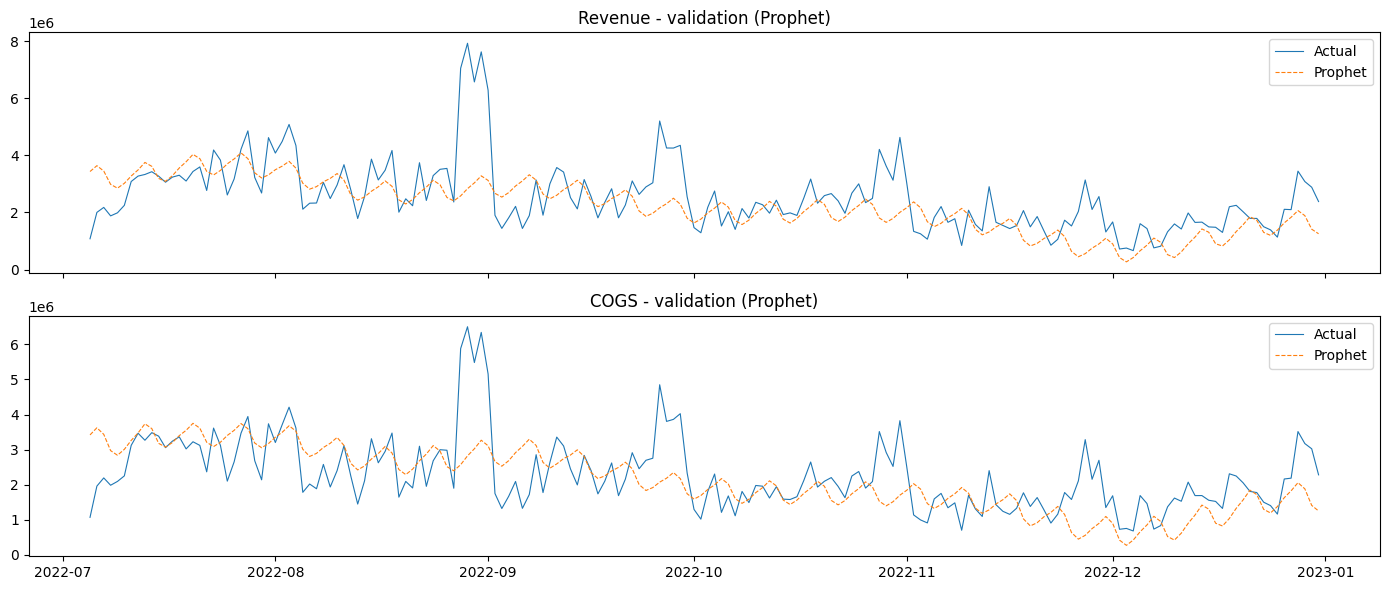

Training Prophet on full data for submission...


10:09:43 - cmdstanpy - INFO - Chain [1] start processing
10:09:44 - cmdstanpy - INFO - Chain [1] done processing
10:09:44 - cmdstanpy - INFO - Chain [1] start processing
10:09:45 - cmdstanpy - INFO - Chain [1] done processing


Saved: ..\data_cleaned\forecast\prophet_submission.csv


,Date,Revenue,COGS
0,2023-01-01,1605162.92,1597137.11
1,2023-01-02,1812330.28,1787144.79
2,2023-01-03,1930246.97,1864031.54
3,2023-01-04,2102973.19,1996264.39
4,2023-01-05,1900078.14,1814636.84
5,2023-01-06,1374098.18,1341698.49
6,2023-01-07,1182802.69,1153506.41
7,2023-01-08,1293087.07,1223254.66
8,2023-01-09,1477865.44,1358939.94
9,2023-01-10,1580833.46,1419033.64


In [51]:
try:
    from prophet import Prophet
except ImportError as exc:
    raise ImportError("prophet is required. Install with: pip install prophet") from exc

prophet_base = train_target[["Date", "Revenue", "COGS"]].copy()
prophet_base = prophet_base.sort_values("Date").reset_index(drop=True)

prophet_train = prophet_base[prophet_base["Date"] <= split_date].copy()
prophet_val = prophet_base[prophet_base["Date"] > split_date].copy()

def fit_prophet(df, target):
    train_df = df[["Date", target]].rename(columns={"Date": "ds", target: "y"})
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode="additive",
    )
    model.fit(train_df)
    return model

def mape(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    eps = 1e-9
    return float(np.mean(np.abs(actual - pred) / (np.abs(actual) + eps)))

def smape(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    eps = 1e-9
    return float(np.mean(2.0 * np.abs(actual - pred) / (np.abs(actual) + np.abs(pred) + eps)))

print("Training Prophet for Revenue...")
rev_model = fit_prophet(prophet_train, "Revenue")
print("Training Prophet for COGS...")
cogs_model = fit_prophet(prophet_train, "COGS")

val_ds = prophet_val[["Date"]].rename(columns={"Date": "ds"})
val_rev_pred = rev_model.predict(val_ds)["yhat"].to_numpy()
val_cogs_pred = cogs_model.predict(val_ds)["yhat"].to_numpy()

val_rev_pred = np.maximum(val_rev_pred, 0.0)
val_cogs_pred = np.maximum(val_cogs_pred, 0.0)
val_cogs_pred = np.minimum(val_cogs_pred, val_rev_pred * 0.995)

score_table_prophet = pd.DataFrame([
    {
        "target": "Revenue",
        "model": "prophet",
        "MAPE": mape(prophet_val["Revenue"], val_rev_pred),
        "SMAPE": smape(prophet_val["Revenue"], val_rev_pred),
    },
    {
        "target": "COGS",
        "model": "prophet",
        "MAPE": mape(prophet_val["COGS"], val_cogs_pred),
        "SMAPE": smape(prophet_val["COGS"], val_cogs_pred),
    },
])

display(score_table_prophet)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(prophet_val["Date"], prophet_val["Revenue"], lw=0.8, label="Actual")
axes[0].plot(prophet_val["Date"], val_rev_pred, lw=0.8, linestyle="--", label="Prophet")
axes[0].set_title("Revenue - validation (Prophet)")
axes[0].legend()

axes[1].plot(prophet_val["Date"], prophet_val["COGS"], lw=0.8, label="Actual")
axes[1].plot(prophet_val["Date"], val_cogs_pred, lw=0.8, linestyle="--", label="Prophet")
axes[1].set_title("COGS - validation (Prophet)")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Training Prophet on full data for submission...")
rev_model_full = fit_prophet(prophet_base, "Revenue")
cogs_model_full = fit_prophet(prophet_base, "COGS")

test_ds = test_feat[["Date"]].rename(columns={"Date": "ds"})
test_rev_pred = rev_model_full.predict(test_ds)["yhat"].to_numpy()
test_cogs_pred = cogs_model_full.predict(test_ds)["yhat"].to_numpy()

test_rev_pred = np.maximum(test_rev_pred, 0.0)
test_cogs_pred = np.maximum(test_cogs_pred, 0.0)
test_cogs_pred = np.minimum(test_cogs_pred, test_rev_pred * 0.995)

submission_prophet = pd.DataFrame({
    "Date": test_feat["Date"].dt.strftime("%Y-%m-%d"),
    "Revenue": np.round(test_rev_pred, 2),
    "COGS": np.round(test_cogs_pred, 2),
})

out_dir = Path("../data_cleaned/forecast")
out_dir.mkdir(parents=True, exist_ok=True)
out_path_prophet = out_dir / "prophet_submission.csv"
submission_prophet.to_csv(out_path_prophet, index=False)

print("Saved:", out_path_prophet)
submission_prophet.head(10)

## 14 - Baseline++ Residual Ridge (Processed Features)
Use Baseline+ as a prior, then learn residuals from the processed feature set.

,target,model,MAPE,SMAPE
0,COGS,baseline_plus,0.175260,0.169234
1,COGS,baseline_plus_residual_ridge,0.305946,0.393066
2,Revenue,baseline_plus,0.172483,0.170726
3,Revenue,baseline_plus_residual_ridge,0.288267,0.366940


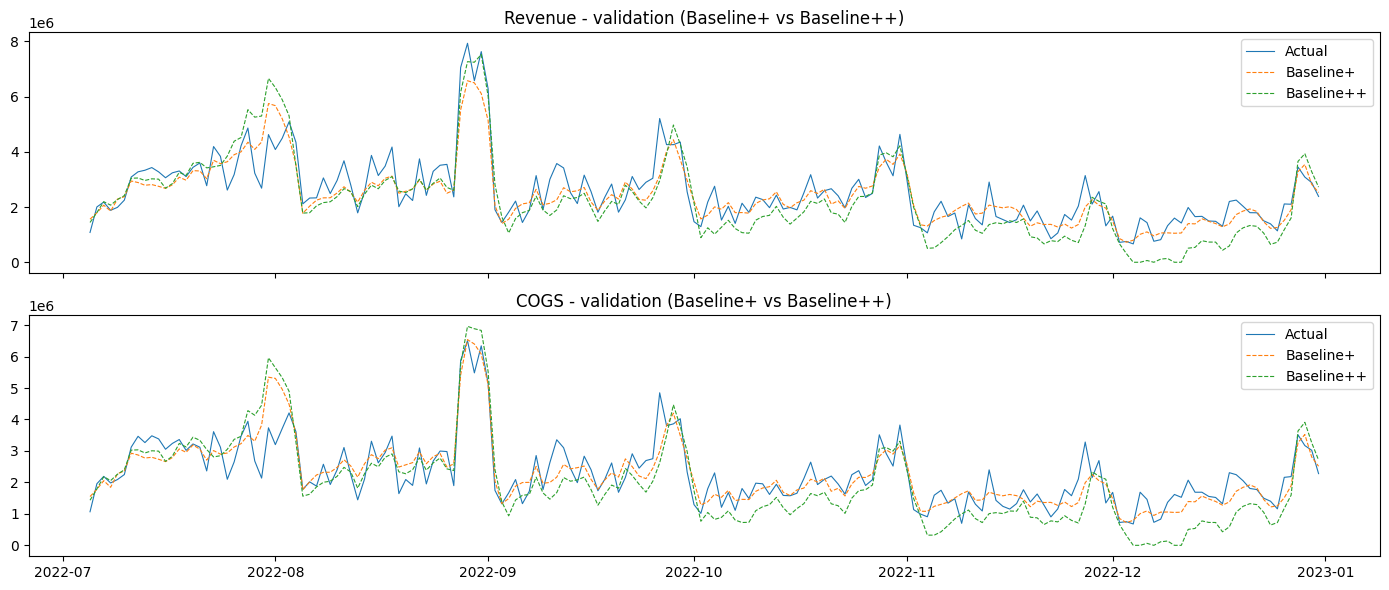

Saved: ..\data_cleaned\forecast\baseline_plus_residual_ridge_submission.csv


,Date,Revenue,COGS
0,2023-01-01,775159.93,771284.13
1,2023-01-02,0.00,0.00
2,2023-01-03,0.00,0.00
3,2023-01-04,0.00,0.00
4,2023-01-05,0.00,0.00
5,2023-01-06,0.00,0.00
6,2023-01-07,0.00,0.00
7,2023-01-08,0.00,0.00
8,2023-01-09,0.00,0.00
9,2023-01-10,0.00,0.00


In [50]:
try:
    from sklearn.linear_model import Ridge
except ImportError as exc:
    raise ImportError("scikit-learn is required. Install with: pip install scikit-learn") from exc

required = ["train_feat", "train_target", "test_feat", "cal"]
missing = [name for name in required if name not in globals()]
if missing:
    raise ValueError(
        "Missing variables: {}. Run Sections 5 and 8 first.".format(", ".join(missing))
    )

baseline_train = cal[["Date", "Revenue_pred_improved", "COGS_pred_improved"]].copy()
train_full = (
    train_feat.merge(train_target, on="Date", how="left")
    .merge(baseline_train, on="Date", how="left")
    .sort_values("Date")
    .reset_index(drop=True)
)

if train_full[["Revenue_pred_improved", "COGS_pred_improved"]].isna().any().any():
    raise ValueError("Baseline+ predictions missing. Re-run Section 5.")

resid_feature_cols = [
    c for c in train_full.columns
    if c not in ["Date", "Revenue", "COGS", "Revenue_pred_improved", "COGS_pred_improved"]
]

X_res_all = train_full[resid_feature_cols].copy()
y_res_all = train_full[["Revenue", "COGS"]].copy()

split_date_used = split_date if "split_date" in globals() else train_full["Date"].max() - pd.Timedelta(days=180)
resid_train_mask = train_full["Date"] <= split_date_used
resid_val_mask = train_full["Date"] > split_date_used

X_res_train = X_res_all.loc[resid_train_mask].copy()
X_res_val = X_res_all.loc[resid_val_mask].copy()
y_res_train = y_res_all.loc[resid_train_mask].copy()
y_res_val = y_res_all.loc[resid_val_mask].copy()

median_values = X_res_train.median(numeric_only=True)
X_res_train = X_res_train.fillna(median_values).fillna(0.0)
X_res_val = X_res_val.fillna(median_values).fillna(0.0)

resid_rev_train = y_res_train["Revenue"] - train_full.loc[resid_train_mask, "Revenue_pred_improved"]
resid_cogs_train = y_res_train["COGS"] - train_full.loc[resid_train_mask, "COGS_pred_improved"]

ridge_rev = Ridge(alpha=10.0)
ridge_cogs = Ridge(alpha=10.0)
ridge_rev.fit(X_res_train, resid_rev_train)
ridge_cogs.fit(X_res_train, resid_cogs_train)

resid_rev_val = ridge_rev.predict(X_res_val)
resid_cogs_val = ridge_cogs.predict(X_res_val)

baseline_val_rev = train_full.loc[resid_val_mask, "Revenue_pred_improved"].to_numpy()
baseline_val_cogs = train_full.loc[resid_val_mask, "COGS_pred_improved"].to_numpy()

val_pred_rev = np.maximum(baseline_val_rev + resid_rev_val, 0.0)
val_pred_cogs = np.maximum(baseline_val_cogs + resid_cogs_val, 0.0)
val_pred_cogs = np.minimum(val_pred_cogs, val_pred_rev * 0.995)

score_table_resid = pd.DataFrame([
    {
        "target": "Revenue",
        "model": "baseline_plus",
        "MAPE": mape(y_res_val["Revenue"], baseline_val_rev),
        "SMAPE": smape(y_res_val["Revenue"], baseline_val_rev),
    },
    {
        "target": "Revenue",
        "model": "baseline_plus_residual_ridge",
        "MAPE": mape(y_res_val["Revenue"], val_pred_rev),
        "SMAPE": smape(y_res_val["Revenue"], val_pred_rev),
    },
    {
        "target": "COGS",
        "model": "baseline_plus",
        "MAPE": mape(y_res_val["COGS"], baseline_val_cogs),
        "SMAPE": smape(y_res_val["COGS"], baseline_val_cogs),
    },
    {
        "target": "COGS",
        "model": "baseline_plus_residual_ridge",
        "MAPE": mape(y_res_val["COGS"], val_pred_cogs),
        "SMAPE": smape(y_res_val["COGS"], val_pred_cogs),
    },
])

score_table_resid = score_table_resid.sort_values(["target", "SMAPE"]).reset_index(drop=True)
display(score_table_resid)

val_dates = train_full.loc[resid_val_mask, "Date"]
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(val_dates, y_res_val["Revenue"], lw=0.8, label="Actual")
axes[0].plot(val_dates, baseline_val_rev, lw=0.8, linestyle="--", label="Baseline+")
axes[0].plot(val_dates, val_pred_rev, lw=0.8, linestyle="--", label="Baseline++")
axes[0].set_title("Revenue - validation (Baseline+ vs Baseline++)")
axes[0].legend()

axes[1].plot(val_dates, y_res_val["COGS"], lw=0.8, label="Actual")
axes[1].plot(val_dates, baseline_val_cogs, lw=0.8, linestyle="--", label="Baseline+")
axes[1].plot(val_dates, val_pred_cogs, lw=0.8, linestyle="--", label="Baseline++")
axes[1].set_title("COGS - validation (Baseline+ vs Baseline++)")
axes[1].legend()

plt.tight_layout()
plt.show()

if "model_test" in globals():
    baseline_test = model_test[["Date", "Revenue_pred", "COGS_pred"]].copy()
elif "test" in globals() and {"Revenue_pred", "COGS_pred"}.issubset(test.columns):
    baseline_test = test[["Date", "Revenue_pred", "COGS_pred"]].copy()
else:
    raise ValueError("Missing Baseline+ test predictions. Re-run Section 5.")

baseline_test = baseline_test.rename(columns={
    "Revenue_pred": "Revenue_pred_improved",
    "COGS_pred": "COGS_pred_improved",
})

test_full = (
    test_feat.merge(baseline_test, on="Date", how="left")
    .sort_values("Date")
    .reset_index(drop=True)
)

X_res_test = test_full.reindex(columns=resid_feature_cols)
X_res_test = X_res_test.fillna(median_values).fillna(0.0)

resid_rev_test = ridge_rev.predict(X_res_test)
resid_cogs_test = ridge_cogs.predict(X_res_test)

test_pred_rev = np.maximum(test_full["Revenue_pred_improved"].to_numpy() + resid_rev_test, 0.0)
test_pred_cogs = np.maximum(test_full["COGS_pred_improved"].to_numpy() + resid_cogs_test, 0.0)
test_pred_cogs = np.minimum(test_pred_cogs, test_pred_rev * 0.995)

submission_resid = pd.DataFrame({
    "Date": test_feat["Date"].dt.strftime("%Y-%m-%d"),
    "Revenue": np.round(test_pred_rev, 2),
    "COGS": np.round(test_pred_cogs, 2),
})

out_dir = Path("../data_cleaned/forecast")
out_dir.mkdir(parents=True, exist_ok=True)
out_path_resid = out_dir / "baseline_plus_residual_ridge_submission.csv"
submission_resid.to_csv(out_path_resid, index=False)

print("Saved:", out_path_resid)
submission_resid.head(10)

## 15 - Baseline+ Residual ElasticNet (Processed Features)
Fit ElasticNet on residuals relative to Baseline+, then predict the test period.

In [61]:
try:
    from sklearn.linear_model import ElasticNet
    from sklearn.model_selection import ParameterGrid
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
except ImportError as exc:
    raise ImportError("scikit-learn is required. Install with: pip install scikit-learn") from exc

required = ["train_feat", "train_target", "test_feat", "cal"]
missing = [name for name in required if name not in globals()]
if missing:
    raise ValueError("Missing variables: {}. Run Sections 5 and 8 first.".format(", ".join(missing)))

baseline_train = cal[["Date", "Revenue_pred_improved", "COGS_pred_improved"]].copy()
train_full = (
    train_feat.merge(train_target, on="Date", how="left")
    .merge(baseline_train, on="Date", how="left")
    .sort_values("Date")
    .reset_index(drop=True)
)

if train_full[["Revenue_pred_improved", "COGS_pred_improved"]].isna().any().any():
    raise ValueError("Baseline+ predictions missing. Re-run Section 5.")

resid_feature_cols = [
    c for c in train_full.columns
    if c not in ["Date", "Revenue", "COGS", "Revenue_pred_improved", "COGS_pred_improved"]
]

X_res_all = train_full[resid_feature_cols].copy()
y_res_all = train_full[["Revenue", "COGS"]].copy()

split_date_used = split_date if "split_date" in globals() else train_full["Date"].max() - pd.Timedelta(days=180)
resid_train_mask = train_full["Date"] <= split_date_used
resid_val_mask = train_full["Date"] > split_date_used

X_res_train = X_res_all.loc[resid_train_mask].copy()
X_res_val = X_res_all.loc[resid_val_mask].copy()
y_res_train = y_res_all.loc[resid_train_mask].copy()
y_res_val = y_res_all.loc[resid_val_mask].copy()

median_values_resid = X_res_train.median(numeric_only=True)
X_res_train = X_res_train.fillna(median_values_resid).fillna(0.0)
X_res_val = X_res_val.fillna(median_values_resid).fillna(0.0)

baseline_val_rev = train_full.loc[resid_val_mask, "Revenue_pred_improved"].to_numpy()
baseline_val_cogs = train_full.loc[resid_val_mask, "COGS_pred_improved"].to_numpy()

resid_rev_train = y_res_train["Revenue"] - train_full.loc[resid_train_mask, "Revenue_pred_improved"]
resid_cogs_train = y_res_train["COGS"] - train_full.loc[resid_train_mask, "COGS_pred_improved"]

resid_rev_val_true = y_res_val["Revenue"].to_numpy() - baseline_val_rev
resid_cogs_val_true = y_res_val["COGS"].to_numpy() - baseline_val_cogs

def mape(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    eps = 1e-9
    return float(np.mean(np.abs(actual - pred) / (np.abs(actual) + eps)))

def mae(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    return float(np.mean(np.abs(actual - pred)))

en_grid = {
    "alpha": [0.001, 0.01, 0.1],
    "l1_ratio": [0.2, 0.5, 0.8],
}

def fit_en_resid(X_train, y_train, X_val, y_val, grid):
    best_params = None
    best_score = np.inf
    best_model = None
    for params in ParameterGrid(grid):
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", ElasticNet(max_iter=5000, **params)),
        ])
        model.fit(X_train, y_train)
        pred = model.predict(X_val)
        score = mae(y_val, pred)
        if score < best_score:
            best_score = score
            best_params = params
            best_model = model
    return best_model, best_params, best_score

print("ElasticNet grid search for Revenue residuals...")
en_resid_rev, best_params_rev, best_score_rev = fit_en_resid(
    X_res_train,
    resid_rev_train,
    X_res_val,
    resid_rev_val_true,
    en_grid,
 )
print("Best ElasticNet params (Revenue):", best_params_rev)
print("Best ElasticNet MAE (residual Revenue):", f"{best_score_rev:.2f}")

print("ElasticNet grid search for COGS residuals...")
en_resid_cogs, best_params_cogs, best_score_cogs = fit_en_resid(
    X_res_train,
    resid_cogs_train,
    X_res_val,
    resid_cogs_val_true,
    en_grid,
 )
print("Best ElasticNet params (COGS):", best_params_cogs)
print("Best ElasticNet MAE (residual COGS):", f"{best_score_cogs:.2f}")

resid_val_rev = en_resid_rev.predict(X_res_val)
resid_val_cogs = en_resid_cogs.predict(X_res_val)

val_pred_rev = np.maximum(baseline_val_rev + resid_val_rev, 0.0)
val_pred_cogs = np.maximum(baseline_val_cogs + resid_val_cogs, 0.0)
val_pred_cogs = np.minimum(val_pred_cogs, val_pred_rev * 0.995)

print("\nValidation Results (Baseline+ Residual ElasticNet):")
print("MAPE Revenue:", f"{mape(y_res_val['Revenue'], val_pred_rev):.4f}")
print("MAE  Revenue:", f"{mae(y_res_val['Revenue'], val_pred_rev):.2f}")
print("MAPE COGS   :", f"{mape(y_res_val['COGS'], val_pred_cogs):.4f}")
print("MAE  COGS   :", f"{mae(y_res_val['COGS'], val_pred_cogs):.2f}")

if "model_test" in globals():
    baseline_test = model_test[["Date", "Revenue_pred", "COGS_pred"]].copy()
elif "test" in globals() and {"Revenue_pred", "COGS_pred"}.issubset(test.columns):
    baseline_test = test[["Date", "Revenue_pred", "COGS_pred"]].copy()
else:
    raise ValueError("Missing Baseline+ test predictions. Re-run Section 5.")
baseline_test = baseline_test.rename(columns={
    "Revenue_pred": "Revenue_pred_improved",
    "COGS_pred": "COGS_pred_improved",
})

test_full = (
    test_feat.merge(baseline_test, on="Date", how="left")
    .sort_values("Date")
    .reset_index(drop=True)
)

X_res_test = test_full.reindex(columns=resid_feature_cols)
X_res_test = X_res_test.fillna(median_values_resid).fillna(0.0)

resid_test_rev = en_resid_rev.predict(X_res_test)
resid_test_cogs = en_resid_cogs.predict(X_res_test)

test_pred_rev = np.maximum(test_full["Revenue_pred_improved"].to_numpy() + resid_test_rev, 0.0)
test_pred_cogs = np.maximum(test_full["COGS_pred_improved"].to_numpy() + resid_test_cogs, 0.0)
test_pred_cogs = np.minimum(test_pred_cogs, test_pred_rev * 0.995)

submission_resid_en = pd.DataFrame({
    "Date": test_feat["Date"].dt.strftime("%Y-%m-%d"),
    "Revenue": np.round(test_pred_rev, 2),
    "COGS": np.round(test_pred_cogs, 2),
})

out_dir = Path("../data_cleaned/forecast")
out_dir.mkdir(parents=True, exist_ok=True)
out_path_resid_en = out_dir / "baseline_plus_residual_elasticnet_submission.csv"
submission_resid_en.to_csv(out_path_resid_en, index=False)

print("Saved:", out_path_resid_en)
submission_resid_en.head(10)

ElasticNet grid search for Revenue residuals...
Best ElasticNet params (Revenue): {'alpha': 0.1, 'l1_ratio': 0.2}
Best ElasticNet MAE (residual Revenue): 569543.12
ElasticNet grid search for COGS residuals...
Best ElasticNet params (COGS): {'alpha': 0.1, 'l1_ratio': 0.2}
Best ElasticNet MAE (residual COGS): 500881.80

Validation Results (Baseline+ Residual ElasticNet):
MAPE Revenue: 0.2571
MAE  Revenue: 567683.30
MAPE COGS   : 0.2723
MAE  COGS   : 545024.76
Saved: ..\data_cleaned\forecast\baseline_plus_residual_elasticnet_submission.csv


,Date,Revenue,COGS
0,2023-01-01,1094662.22,1089188.91
1,2023-01-02,43204.26,42988.23
2,2023-01-03,0.00,0.00
3,2023-01-04,0.00,0.00
4,2023-01-05,0.00,0.00
5,2023-01-06,0.00,0.00
6,2023-01-07,0.00,0.00
7,2023-01-08,0.00,0.00
8,2023-01-09,83700.75,15730.33
9,2023-01-10,239502.18,120710.58


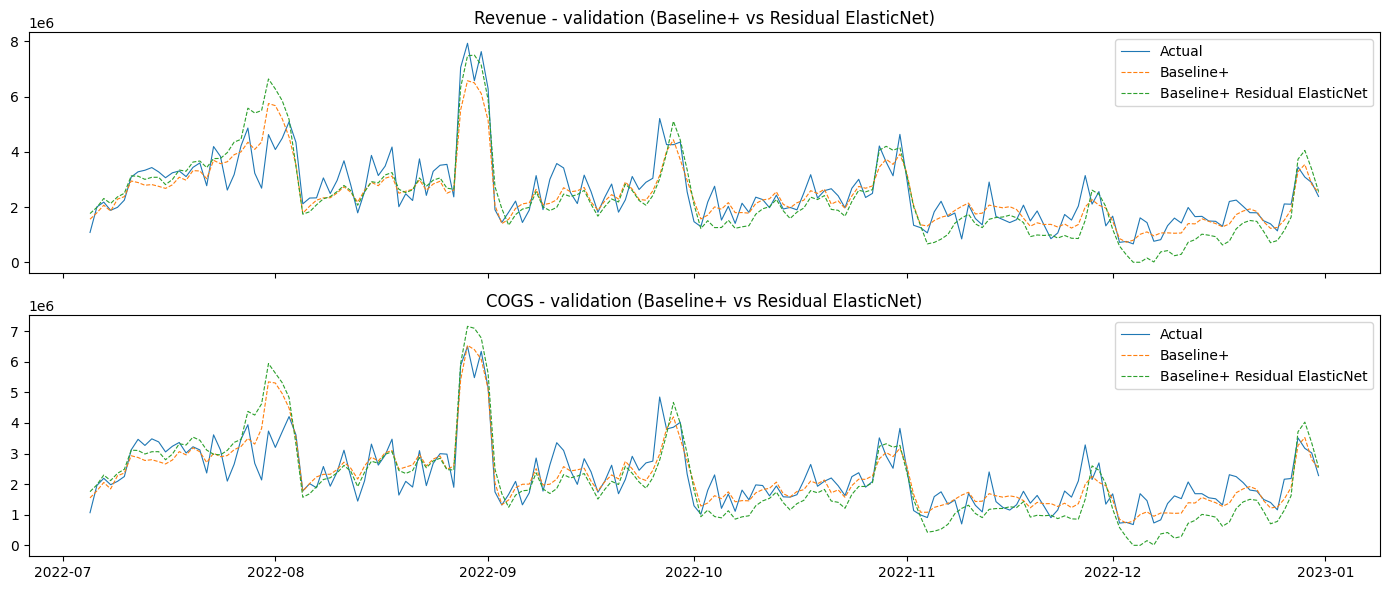

In [62]:
val_dates = train_full.loc[resid_val_mask, "Date"].reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(val_dates, y_res_val["Revenue"], lw=0.8, label="Actual")
axes[0].plot(val_dates, baseline_val_rev, lw=0.8, linestyle="--", label="Baseline+")
axes[0].plot(val_dates, val_pred_rev, lw=0.8, linestyle="--", label="Baseline+ Residual ElasticNet")
axes[0].set_title("Revenue - validation (Baseline+ vs Residual ElasticNet)")
axes[0].legend()

axes[1].plot(val_dates, y_res_val["COGS"], lw=0.8, label="Actual")
axes[1].plot(val_dates, baseline_val_cogs, lw=0.8, linestyle="--", label="Baseline+")
axes[1].plot(val_dates, val_pred_cogs, lw=0.8, linestyle="--", label="Baseline+ Residual ElasticNet")
axes[1].set_title("COGS - validation (Baseline+ vs Residual ElasticNet)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [63]:
try:
    import lightgbm as lgb
except ImportError as exc:
    raise ImportError("lightgbm is required. Install with: pip install lightgbm") from exc

required = ["train_feat", "train_target", "test_feat", "cal"]
missing = [name for name in required if name not in globals()]
if missing:
    raise ValueError("Missing variables: {}. Run Sections 5 and 8 first.".format(", ".join(missing)))

baseline_train_lgbm = cal[["Date", "Revenue_pred_improved", "COGS_pred_improved"]].copy()
train_full_lgbm = (
    train_feat.merge(train_target, on="Date", how="left")
    .merge(baseline_train_lgbm, on="Date", how="left")
    .sort_values("Date")
    .reset_index(drop=True)
)

if train_full_lgbm[["Revenue_pred_improved", "COGS_pred_improved"]].isna().any().any():
    raise ValueError("Baseline+ predictions missing. Re-run Section 5.")

resid_feature_cols_lgbm = [
    c for c in train_full_lgbm.columns
    if c not in ["Date", "Revenue", "COGS", "Revenue_pred_improved", "COGS_pred_improved"]
]

X_res_all_lgbm = train_full_lgbm[resid_feature_cols_lgbm].copy()
y_res_all_lgbm = train_full_lgbm[["Revenue", "COGS"]].copy()

split_date_used = split_date if "split_date" in globals() else train_full_lgbm["Date"].max() - pd.Timedelta(days=180)
resid_train_mask_lgbm = train_full_lgbm["Date"] <= split_date_used
resid_val_mask_lgbm = train_full_lgbm["Date"] > split_date_used

X_res_train_lgbm = X_res_all_lgbm.loc[resid_train_mask_lgbm].copy()
X_res_val_lgbm = X_res_all_lgbm.loc[resid_val_mask_lgbm].copy()
y_res_train_lgbm = y_res_all_lgbm.loc[resid_train_mask_lgbm].copy()
y_res_val_lgbm = y_res_all_lgbm.loc[resid_val_mask_lgbm].copy()

median_values_resid_lgbm = X_res_train_lgbm.median(numeric_only=True)
X_res_train_lgbm = X_res_train_lgbm.fillna(median_values_resid_lgbm).fillna(0.0)
X_res_val_lgbm = X_res_val_lgbm.fillna(median_values_resid_lgbm).fillna(0.0)

baseline_val_rev_lgbm = train_full_lgbm.loc[resid_val_mask_lgbm, "Revenue_pred_improved"].to_numpy()
baseline_val_cogs_lgbm = train_full_lgbm.loc[resid_val_mask_lgbm, "COGS_pred_improved"].to_numpy()

resid_rev_train_lgbm = y_res_train_lgbm["Revenue"] - train_full_lgbm.loc[resid_train_mask_lgbm, "Revenue_pred_improved"]
resid_cogs_train_lgbm = y_res_train_lgbm["COGS"] - train_full_lgbm.loc[resid_train_mask_lgbm, "COGS_pred_improved"]

resid_rev_val_true_lgbm = y_res_val_lgbm["Revenue"].to_numpy() - baseline_val_rev_lgbm
resid_cogs_val_true_lgbm = y_res_val_lgbm["COGS"].to_numpy() - baseline_val_cogs_lgbm

def mape(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    eps = 1e-9
    return float(np.mean(np.abs(actual - pred) / (np.abs(actual) + eps)))

def mae(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    return float(np.mean(np.abs(actual - pred)))

lgb_mae_params = {
    "objective": "regression_l1",
    "metric": "l1",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": 8,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbosity": -1,
}

lgb_train_rev_mae = lgb.Dataset(
    X_res_train_lgbm,
    label=resid_rev_train_lgbm,
    feature_name=list(X_res_train_lgbm.columns),
    free_raw_data=False,
 )
lgb_val_rev_mae = lgb.Dataset(
    X_res_val_lgbm,
    label=resid_rev_val_true_lgbm,
    reference=lgb_train_rev_mae,
    free_raw_data=False,
 )

lgb_train_cogs_mae = lgb.Dataset(
    X_res_train_lgbm,
    label=resid_cogs_train_lgbm,
    feature_name=list(X_res_train_lgbm.columns),
    free_raw_data=False,
 )
lgb_val_cogs_mae = lgb.Dataset(
    X_res_val_lgbm,
    label=resid_cogs_val_true_lgbm,
    reference=lgb_train_cogs_mae,
    free_raw_data=False,
 )

print("Training Residual LightGBM (MAE) for Revenue...")
lgb_rev_mae = lgb.train(
    lgb_mae_params,
    lgb_train_rev_mae,
    num_boost_round=1500,
    valid_sets=[lgb_val_rev_mae],
    callbacks=[lgb.early_stopping(100, verbose=False)],
 )

print("Training Residual LightGBM (MAE) for COGS...")
lgb_cogs_mae = lgb.train(
    lgb_mae_params,
    lgb_train_cogs_mae,
    num_boost_round=1500,
    valid_sets=[lgb_val_cogs_mae],
    callbacks=[lgb.early_stopping(100, verbose=False)],
 )

resid_val_rev_lgbm = lgb_rev_mae.predict(X_res_val_lgbm)
resid_val_cogs_lgbm = lgb_cogs_mae.predict(X_res_val_lgbm)

val_pred_rev_lgbm = np.maximum(baseline_val_rev_lgbm + resid_val_rev_lgbm, 0.0)
val_pred_cogs_lgbm = np.maximum(baseline_val_cogs_lgbm + resid_val_cogs_lgbm, 0.0)
val_pred_cogs_lgbm = np.minimum(val_pred_cogs_lgbm, val_pred_rev_lgbm * 0.995)

print("\nValidation Results (Baseline+ Residual LGBM MAE):")
print("MAPE Revenue:", f"{mape(y_res_val_lgbm['Revenue'], val_pred_rev_lgbm):.4f}")
print("MAE  Revenue:", f"{mae(y_res_val_lgbm['Revenue'], val_pred_rev_lgbm):.2f}")
print("MAPE COGS   :", f"{mape(y_res_val_lgbm['COGS'], val_pred_cogs_lgbm):.4f}")
print("MAE  COGS   :", f"{mae(y_res_val_lgbm['COGS'], val_pred_cogs_lgbm):.2f}")

if "model_test" in globals():
    baseline_test_lgbm = model_test[["Date", "Revenue_pred", "COGS_pred"]].copy()
elif "test" in globals() and {"Revenue_pred", "COGS_pred"}.issubset(test.columns):
    baseline_test_lgbm = test[["Date", "Revenue_pred", "COGS_pred"]].copy()
else:
    raise ValueError("Missing Baseline+ test predictions. Re-run Section 5.")
baseline_test_lgbm = baseline_test_lgbm.rename(columns={
    "Revenue_pred": "Revenue_pred_improved",
    "COGS_pred": "COGS_pred_improved",
})

test_full_lgbm = (
    test_feat.merge(baseline_test_lgbm, on="Date", how="left")
    .sort_values("Date")
    .reset_index(drop=True)
)

X_res_test_lgbm = test_full_lgbm.reindex(columns=resid_feature_cols_lgbm)
X_res_test_lgbm = X_res_test_lgbm.fillna(median_values_resid_lgbm).fillna(0.0)

resid_test_rev_lgbm = lgb_rev_mae.predict(X_res_test_lgbm)
resid_test_cogs_lgbm = lgb_cogs_mae.predict(X_res_test_lgbm)

test_pred_rev_lgbm = np.maximum(
    test_full_lgbm["Revenue_pred_improved"].to_numpy() + resid_test_rev_lgbm, 0.0
 )
test_pred_cogs_lgbm = np.maximum(
    test_full_lgbm["COGS_pred_improved"].to_numpy() + resid_test_cogs_lgbm, 0.0
 )
test_pred_cogs_lgbm = np.minimum(test_pred_cogs_lgbm, test_pred_rev_lgbm * 0.995)

submission_resid_lgbm_mae = pd.DataFrame({
    "Date": test_feat["Date"].dt.strftime("%Y-%m-%d"),
    "Revenue": np.round(test_pred_rev_lgbm, 2),
    "COGS": np.round(test_pred_cogs_lgbm, 2),
})

out_dir = Path("../data_cleaned/forecast")
out_dir.mkdir(parents=True, exist_ok=True)
out_path_resid_lgbm_mae = out_dir / "baseline_plus_residual_lgbm_mae_submission.csv"
submission_resid_lgbm_mae.to_csv(out_path_resid_lgbm_mae, index=False)

print("Saved:", out_path_resid_lgbm_mae)
submission_resid_lgbm_mae.head(10)

Training Residual LightGBM (MAE) for Revenue...
Training Residual LightGBM (MAE) for COGS...

Validation Results (Baseline+ Residual LGBM MAE):
MAPE Revenue: 0.1854
MAE  Revenue: 416976.18
MAPE COGS   : 0.1789
MAE  COGS   : 355607.38
Saved: ..\data_cleaned\forecast\baseline_plus_residual_lgbm_mae_submission.csv


,Date,Revenue,COGS
0,2023-01-01,2556407.84,2543625.80
1,2023-01-02,1316385.91,1135582.16
2,2023-01-03,1030672.76,859062.19
3,2023-01-04,1235987.12,952851.31
4,2023-01-05,1330344.36,781479.59
5,2023-01-06,1222749.69,926505.88
6,2023-01-07,1241335.83,1052493.95
7,2023-01-08,1453771.55,1236076.12
8,2023-01-09,1638617.50,1275262.88
9,2023-01-10,1781357.57,1417355.56
